# **Проверка гипотез**

### **Импорт библиотек, загрузка данных, настройка ноутбука**






In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, ttest_ind, pearsonr, levene, entropy, spearmanr, normaltest
import warnings
warnings.filterwarnings('ignore')

In [25]:
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

In [26]:
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [27]:
sns.set_theme(style="darkgrid")

In [28]:
data_raw = pd.read_csv('parkinsons.data')
data = data_raw.copy(deep=True)

data['status_name'] = data['status'].map({0: 'Здоровый', 1: 'БП'})

healthy = data[data['status'] == 0]
parkinson = data[data['status'] == 1]


### **Информация о гипотезах**


Гипотезы о наличии или отсутствии связи голосовых параметров с болезнью Паркинсона были основаны на следующей группировке признаков:




| № | Группа параметров | Проверяемые признаки |
|:--|:------------------|:---------------------|
| 1 | Shimmer (амплитудная нестабильность) | MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA |
| 2 | Jitter (частотная нестабильность) | MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP |
| 3 | Основная частота (F0) | MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz) |
| 4 | Нелинейные параметры  | spread1, spread2, PPE |
| 5 | Нелинейные параметры + шумовые параметры | RPDE, D2, HNR, NHR |




Так как при проведении EDA мы узнали, что в данных нет пропусков и все типы корректны, предобработка не нужна.







## **1. Shimmer**
Исследование связи голосовых показателей колебаний амплитуды и наличия болезни Паркинсона

Проверка гипотез о влиянии показателей колебаний амплитуды (MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA) и наличия болезни Паркинсона.

**Обоснование.** Shimmer показывает, насколько нестабильна амплитуда звука от цикла к циклу. Рост shimmer часто связан с:

- гипотонией/неустойчивым смыканием голосовых складок;
- «воздушностью»/утечкой воздуха, слабостью фонации.

При Паркинсоне это может отражать явление гипофонии и ухудшение контроля фонации. В литературе показатели Shimmer исследуются как ключевые маркеры гипокинезии гортани.

In [29]:
rng = np.random.default_rng(42)

Перед проверкой гипотез данные необходимо предобработать. Так как в датасете на одного пациента приходится несколько записей, чтобы их искусственно не раздувать, их необходимо агрегировать. Тесты будем проводить на агрегированных данных.

In [30]:
data1 = data_raw.copy(deep=True)

# Отбираем нужные признаки и целевую переменную
shimmer_cols = ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3',
             'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA']
data1 = data1[['name'] + shimmer_cols + ['status']]

# Агрегируем по пациенту: извлекаем ID пациента из имени записи
# и усредняем все записи одного пациента
data1['patient_id'] = data1['name'].str.extract(r'(phon_R\d+_S\d+)')
data1 = (data1.groupby('patient_id', as_index=False)
              .agg({**{col: 'mean' for col in shimmer_cols}, 'status': 'first'}))

data1['status_name'] = data1['status'].map({0: 'Здоровый', 1: 'БП'})

print(f'Пациентов после агрегации: {len(data1)} '
      f'(здоровых: {(data1.status==0).sum()}, с БП: {(data1.status==1).sum()})')

Пациентов после агрегации: 32 (здоровых: 8, с БП: 24)


### План тестов

Для проверки гипотез о различии признаков между группами применяется следующий подход:

1. **Тест Шапиро-Уилка** на исходных данных -- фиксируем нормальность/ненормальность.
2. **Логарифмирование**  -- стандартное преобразование для скошенных данных.
3. **Повторный тест Шапиро-Уилка** на логарифмированных данных -- оцениваем улучшение.

Здесь можно сразу применить t-тест Уэлча, но, как мне кажется, выборки слишком малы, чтобы пренебрегать скошенностью распределения даже после логарифмирования. Даже если данные взяты из нормального распределения, обнаружить это на выборке из 8 величин может быть сложно, мощность теста падает. Поэтому в каждом случае я провожу тест Шапиро–Уилка, чтобы убедиться в этом.

4. **Гистограммы** исходного и логарифмированного распределений -- проверяем визуально.
5. **Перестановочный тест** (permutation test) по разности средних -- не требует предположений о форме распределения, устойчив к малым выборкам.

### Общие функции

In [31]:
# Проводим тест Шапиро-Уилка
def shapiro_report(values, status_name):

    _, p = shapiro(values)
    ans = 'нормально' if p >= 0.05 else 'НЕ нормально'
    print(f'{status_name}: p={p:.4f} -> {ans}')
    return p

In [32]:
# Отрисовываем гистограммы распределений
def plot_distributions(col, data, title_suffix=''):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (vals, label) in zip(axes, [(data[col], f'{col} (исходное)'),
                                        (np.log(data[col]), f'log({col}) (после преобразования)')]):

        tmp = data.copy()
        tmp['_x'] = vals
        sns.histplot(data=tmp, x='_x', hue='status_name',
                     bins=20, kde=True, stat='density', common_norm=False,
                     alpha=0.6, ax=ax)
        ax.set_title(label)
        ax.set_xlabel('')

    plt.suptitle(f'Распределение признака: {col}{title_suffix}', y=1.02)
    plt.tight_layout()
    plt.show()

In [33]:
# t-тест Уэлча
def welch_ttest(group0, group1):

    _, p = ttest_ind(group0, group1, equal_var=False, alternative='two-sided')
    return p

In [34]:
# Перестановочный тест
def permutation_test(group0, group1, n_permutations, rng=rng):

    stat_true = np.abs(np.mean(group1) - np.mean(group0))
    combined = np.concatenate([group0, group1])
    n0 = len(group0)

    count = 0
    for _ in range(n_permutations):
        perm = rng.permutation(combined)
        stat = np.abs(np.mean(perm[n0:]) - np.mean(perm[:n0]))
        if stat >= stat_true:
            count += 1

    p_value = count / n_permutations
    return p_value

In [35]:
# Общая функция всей проверки
def analyze_feature(col, data, n_permutations=1000, alpha=0.05):

    print(f'\n\n\n {'='*70} Признак: {col} {'='*70}')

    g0 = data[data['status'] == 0][col].values
    g1 = data[data['status'] == 1][col].values

    # --- 1: ШУ на исходных данных ---
    print('\n1. Тест Шапиро–Уилка (исходное распределение):')
    shapiro_report(g0, 'Здоровые')
    shapiro_report(g1, 'БП')

    # --- 2: логарифмирование ---
    g0_log = np.log(g0)
    g1_log = np.log(g1)

    # --- 3: ШУ на логарифмированных данных ---
    print('\n2. Тест Шапиро–Уилка (после логарифмирования):')
    shapiro_report(g0_log, 'Здоровые')
    shapiro_report(g1_log, 'БП')

    # --- 4: гистограммы ---
    plot_distributions(col, data)

    # --- 5: t-тест Уэлча ---
    print(f'\n3. t-тест Уэлча:')
    p_welch = welch_ttest(g0_log, g1_log)
    ans = 'статистически значимо' if p_welch < alpha else 'статистически НЕ значимо'
    print(f'p-value: {p_welch:.4f} -> {ans}')

    # --- 6: перестановочный тест ---
    print(f'\n4. Перестановочный тест ({n_permutations} перестановок, разность средних log):')
    p_perm = permutation_test(g0_log, g1_log, n_permutations)
    ans = 'статистически значимо' if p_perm < alpha else 'статистически НЕ значимо'
    print(f'p-value: {p_perm:.4f} -> {ans}')

    return p_welch, p_perm

### Гипотезы

Для каждого признака из группы Shimmer:

- **H0**: распределения признака в группе здоровых и группе с БП одинаковы.
- **H1**: распределения различаются.




 ====================================================================== Признак: MDVP:Shimmer ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.6274 -> нормально
БП: p=0.0531 -> нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.8131 -> нормально
БП: p=0.8735 -> нормально


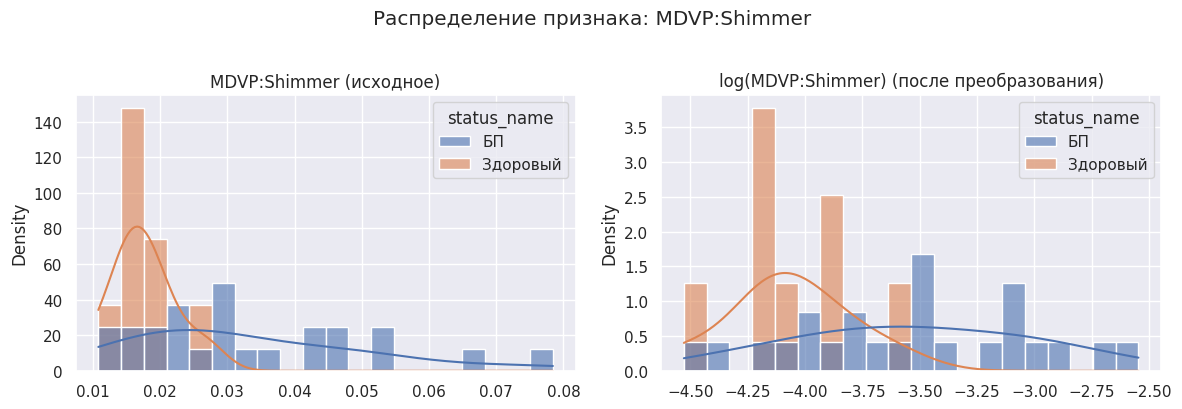


3. t-тест Уэлча:
p-value: 0.0008 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0105 -> статистически значимо



 ====================================================================== Признак: MDVP:Shimmer(dB) ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.2556 -> нормально
БП: p=0.0078 -> НЕ нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.6764 -> нормально
БП: p=0.9307 -> нормально


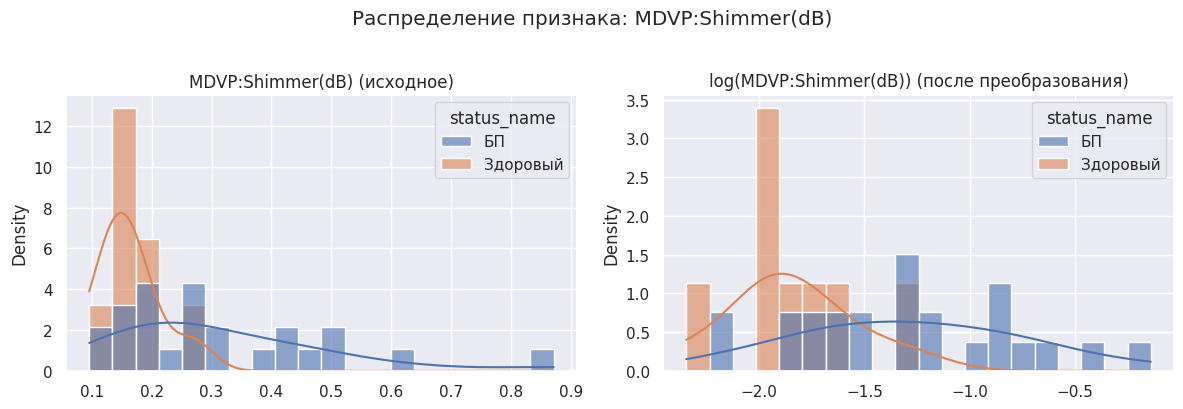


3. t-тест Уэлча:
p-value: 0.0012 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0050 -> статистически значимо



 ====================================================================== Признак: Shimmer:APQ3 ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.8272 -> нормально
БП: p=0.0848 -> нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.9791 -> нормально
БП: p=0.6480 -> нормально


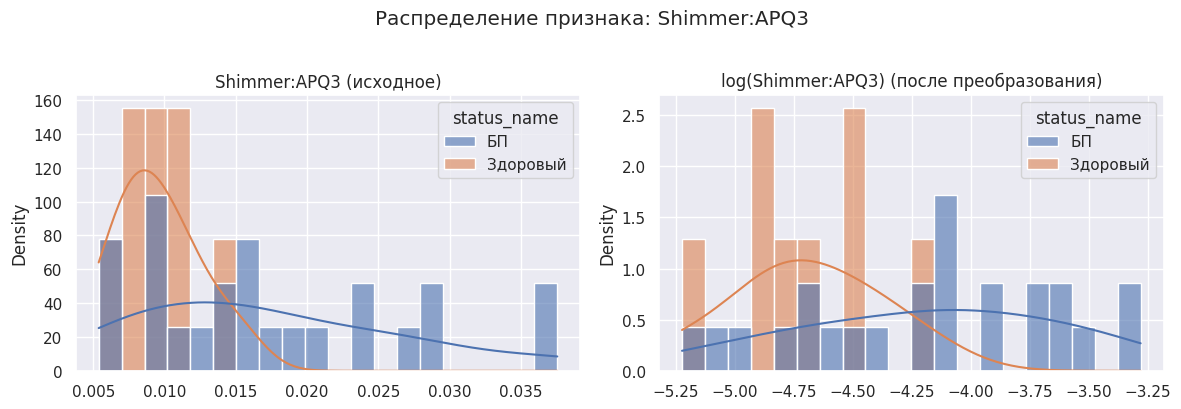


3. t-тест Уэлча:
p-value: 0.0038 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0208 -> статистически значимо



 ====================================================================== Признак: Shimmer:APQ5 ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.2379 -> нормально
БП: p=0.0178 -> НЕ нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.5587 -> нормально
БП: p=0.8467 -> нормально


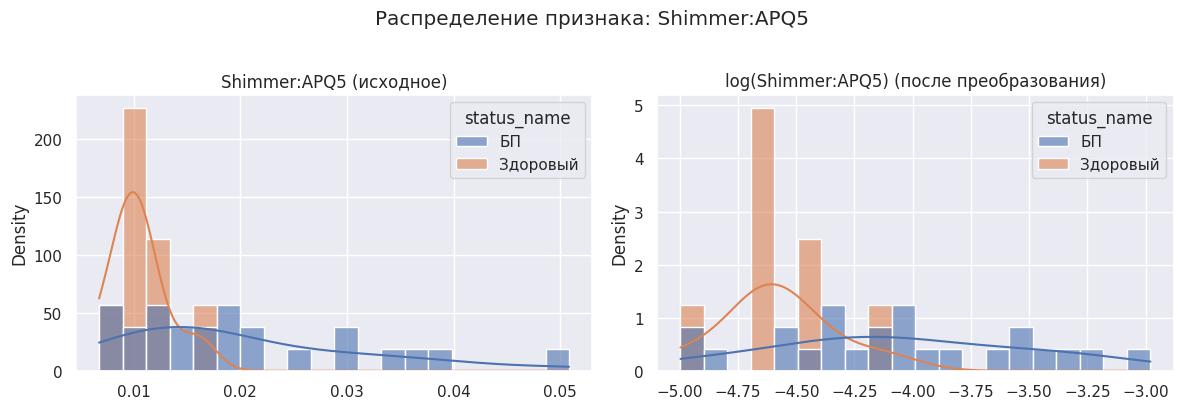


3. t-тест Уэлча:
p-value: 0.0008 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0103 -> статистически значимо



 ====================================================================== Признак: MDVP:APQ ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.9809 -> нормально
БП: p=0.0011 -> НЕ нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.9044 -> нормально
БП: p=0.8646 -> нормально


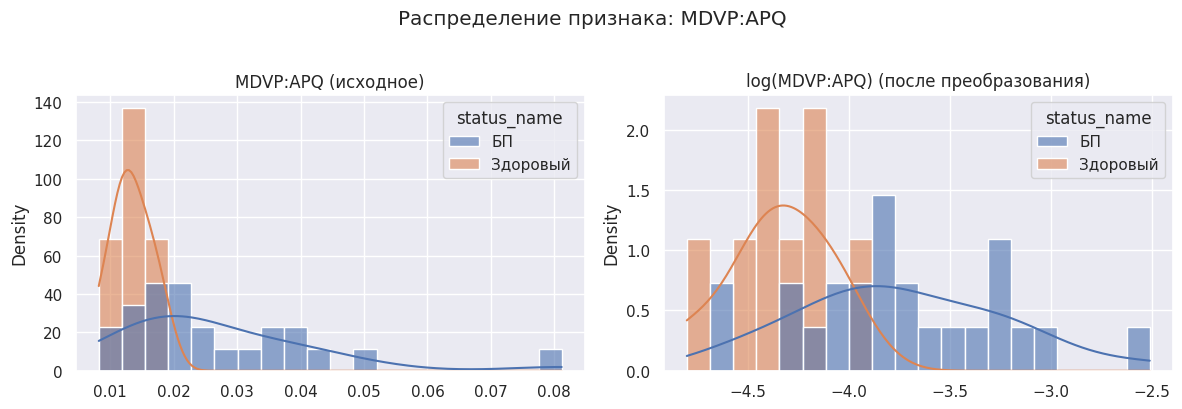


3. t-тест Уэлча:
p-value: 0.0002 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0047 -> статистически значимо



 ====================================================================== Признак: Shimmer:DDA ======================================================================

1. Тест Шапиро–Уилка (исходное распределение):
Здоровые: p=0.8278 -> нормально
БП: p=0.0848 -> нормально

2. Тест Шапиро–Уилка (после логарифмирования):
Здоровые: p=0.9792 -> нормально
БП: p=0.6486 -> нормально


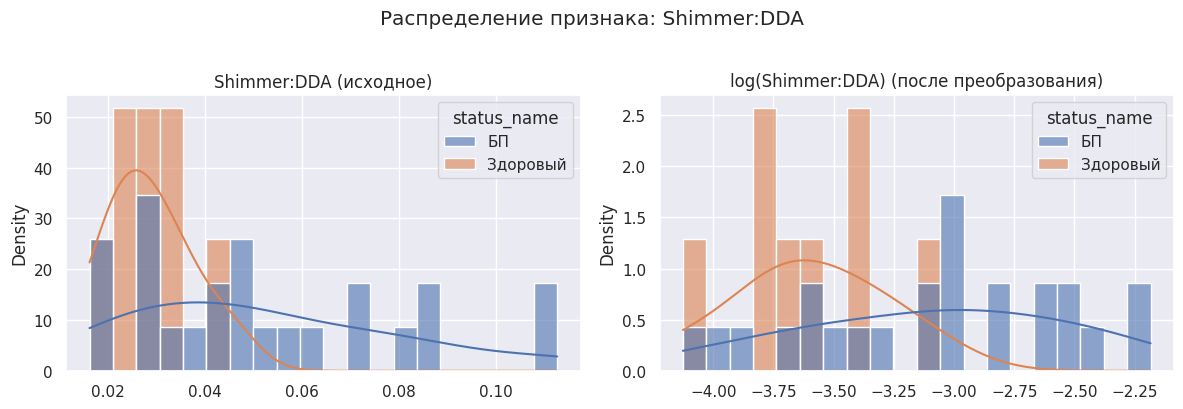


3. t-тест Уэлча:
p-value: 0.0038 -> статистически значимо

4. Перестановочный тест (4000 перестановок, разность средних log):
p-value: 0.0200 -> статистически значимо


In [36]:
alpha = 0.05
n_permutations = 4000
p_perms = {}
p_welchs = {}

for col in shimmer_cols:
    p_welchs[col], p_perms[col] = analyze_feature(col, data1,
                                                   n_permutations=n_permutations,
                                                   alpha=alpha)

### Поправка Бонферрони

С увеличением числа тестов вероятность случайно получить p-value < 0.05 также возрастает. Чтобы учесть это при формулировании выводов, введем поправку Бонферрони.

In [37]:
n_tests = len(shimmer_cols)
alpha_bonf = alpha / n_tests
p_values = {k: (p_perms[k], p_welchs[k]) for k in p_perms.keys()}

print(f'Скорректированный порог Бонферрони: 0.05 / {n_tests} = {alpha_bonf:.4f}\n')
print(f'{"Признак":<22}  {"p-value perm":<17} {"p-value welch":<17} {"Вывод"}')
print('-' * 70)

for col, (p1, p2) in p_values.items():
  ans = "значимо" if p1 <= alpha_bonf and p2 <= alpha_bonf else "НЕ значимо"
  print(f'{col:<22}  {p1:<17.4f}  {p2:<17.4f} {ans}')

Скорректированный порог Бонферрони: 0.05 / 6 = 0.0083

Признак                 p-value perm      p-value welch     Вывод
----------------------------------------------------------------------
MDVP:Shimmer            0.0105             0.0008            НЕ значимо
MDVP:Shimmer(dB)        0.0050             0.0012            значимо
Shimmer:APQ3            0.0208             0.0038            НЕ значимо
Shimmer:APQ5            0.0103             0.0008            НЕ значимо
MDVP:APQ                0.0047             0.0002            значимо
Shimmer:DDA             0.0200             0.0038            НЕ значимо


### Выводы

В большинстве случаев тест Шапиро–Уилка показывал, что исходные данные в группе здоровых распределеены не нормально. При этом он также показывал, что данные распределены нормально в группе больных дя всех признаков. Сильно доверять этим результатам нельзя, так как выборки в группах очень маленькие. В данном случае результаты теста можно трактовать как "не нашлось достаточно оснований, говорить, что выборки не нормалны", даже если это не так. После логарифмирования тест уже чаще выявлял нормальность, но все еще не уверенно

Именно поэтому для проверки гипотез применен **t-тест Уэлча** в комбинации с **перестановочным тестом**: первый устойчив к выборкам с разными дисперсиями (но все еще использует предположение о нормальности, что критично дя маленьких выборок), второй не требует нормальности, работает с любым размером выборки и легко интерпретируется.

**Результаты**  
Перестановочный тест и t-тест Уэлча с поправкой Бонферрони показали статистически значимые различия только по двуи из шести признакам Shimmer между группой здоровых и группой с болезнью Паркинсона.

| Признак | p-value (перест.) | p-value (Уэлч) | Значим |
|---|---|---|---|
| MDVP:Shimmer | 0.0105 | 0.0008 | нет |
| MDVP:Shimmer(dB) | 0.0050 | 0.0012 | **ДА** |
| Shimmer:APQ3 | 0.0208 | 0.0038 | нет |
| Shimmer:APQ5 | 0.0103 | 0.0008 | нет |
| MDVP:APQ | 0.0047 | 0.0002 | **ДА** |
| Shimmer:DDA | 0.0200 | 0.0038 | нет |

Из тестов получается, что только два показателя колебаний амплитуды голоса статистически значимо выше у пациентов с болезнью Паркинсона -- MDVP:Shimmer(dB) и MDVP:APQ. Из таблицы видно, что перестановочный тест дает оценку строже теста Уэлча. Такой строгий отбор наличия эффекта связан с очень маленьким размером выборки. Зато можем сказать, что мы уверены в значимости признаков с обнаруженным эффектом.

## **2. Jitter**

**Обоснование.** Jitter — это показатель, который отражает нестабильность частоты голосового сигнала от цикла к циклу. Проще говоря, он показывает, насколько ровно звучит голос человека.

При болезни Паркинсона происходит поражение нервной системы, из-за чего нарушается контроль над мышцами, в том числе мышцами гортани. Это приводит к дрожанию и нестабильности голосовых складок. В результате голос становится менее устойчивым, а значение jitter увеличивается.

Таким образом, можно предположить, что у пациентов с болезнью Паркинсона показатель jitter будет выше, чем у здоровых людей.


**Гипотеза**

Нестабильность частоты (Jitter) выше у пациентов с болезнью Паркинсона

Нулевая гипотеза (H₀): Медианные значения jitter у пациентов с болезнью Паркинсона и у здоровых людей не отличаются. H₀: median(jitter_PD) = median(jitter_healthy).

Альтернативная гипотеза (H₁): У пациентов с болезнью Паркинсона показатель jitter выше, чем у здоровых. H₁: median(jitter_PD) > median(jitter_healthy).



**Стратегия анализа:**
1. Описательная статистика
Сначала будут рассчитаны основные показатели: медиана, межквартильный размах (IQR) и асимметрия. Это поможет понять распределение данных.
2. Проверка нормальности распределения
Для оценки нормальности будет использован тест Шапиро–Уилка. Также будут проанализированы возможные выбросы.
3. Сравнение групп
Поскольку данные могут не подчиняться нормальному распределению, для сравнения будет применён непараметрический критерий Манна–Уитни. Дополнительно будет рассчитан размер эффекта (rank-biserial r), чтобы оценить силу различий.
4. Поправка на множественные сравнения
Чтобы снизить вероятность ошибки первого рода, будут использованы поправки Бонферрони и Холма–Бонферрони.
5. Анализ корреляций
Будет построена матрица корреляций для выявления взаимосвязей между признаками и проверки мультиколлинеарности.
6. Визуализация данных
Для наглядного анализа планируется использовать:
 - violin-диаграммы,
 - графики плотности распределения (KDE),
 - попарные диаграммы рассеяния (scatter plot).

In [ ]:
JITTER_FEATS = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)',
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP'
]

rows = []


for f in JITTER_FEATS:
    healthy_data = healthy[f].dropna()
    parkinson_data = parkinson[f].dropna()

    rows.append({
        'Признак': f,
        'Мед. здор.': round(healthy_data.median(), 6),
        'IQR здор.': round(healthy_data.quantile(0.75) - healthy_data.quantile(0.25), 6),
        'Асимм. здор.': round(healthy_data.skew(), 2),
        'Мед. ПБ': round(parkinson_data.median(), 6),
        'IQR ПБ': round(parkinson_data.quantile(0.75) - parkinson_data.quantile(0.25), 6),
        'Асимм. ПБ': round(parkinson_data.skew(), 2),
        'Δ медианы (%)': round(
            (parkinson_data.median() / healthy_data.median() - 1) * 100, 1
        )
    })

desc_j = pd.DataFrame(rows)

print("=== 2.1 Дескриптивная статистика (Jitter) ===")
print(desc_j)



=== 2.1 Дескриптивная статистика (Jitter) ===
            Признак  Мед. здор.  IQR здор.  Асимм. здор.  Мед. ПБ  IQR ПБ  \
0    MDVP:Jitter(%)      0.0034     0.0019        2.6000   0.0054  0.0037   
1  MDVP:Jitter(Abs)      0.0000     0.0000        1.2000   0.0000  0.0000   
2          MDVP:RAP      0.0016     0.0006        2.2300   0.0028  0.0021   
3          MDVP:PPQ      0.0018     0.0007        1.9000   0.0031  0.0022   
4        Jitter:DDP      0.0049     0.0017        2.2300   0.0085  0.0062   

   Асимм. ПБ  Δ медианы (%)  
0     2.8600        62.1000  
1     2.5500        60.0000  
2     3.0600        74.8000  
3     2.7900        76.9000  
4     3.0600        75.0000  


In [ ]:
print('=== 2.2 Нормальность (Шапиро–Уилк) ===')

for f in JITTER_FEATS:
    h = healthy[f].dropna()
    p = parkinson[f].dropna()

    stat_h, p_h = shapiro(h)
    stat_p, p_p = shapiro(p)

    print(f'\nПризнак: {f}')
    print(f'Здоровые: p = {round(p_h, 4)}')
    print(f'Паркинсон: p = {round(p_p, 4)}')

print('\nТак как нормальность в большинстве случаев нарушена, используем критерий Манна–Уитни.')

=== 2.2 Нормальность (Шапиро–Уилк) ===

Признак: MDVP:Jitter(%)
Здоровые: p = 0.0
Паркинсон: p = 0.0

Признак: MDVP:Jitter(Abs)
Здоровые: p = 0.0
Паркинсон: p = 0.0

Признак: MDVP:RAP
Здоровые: p = 0.0
Паркинсон: p = 0.0

Признак: MDVP:PPQ
Здоровые: p = 0.0
Паркинсон: p = 0.0

Признак: Jitter:DDP
Здоровые: p = 0.0
Паркинсон: p = 0.0

Так как нормальность в большинстве случаев нарушена, используем критерий Манна–Уитни.


In [ ]:
print('=== Анализ выбросов (метод IQR) ===')

for feature in JITTER_FEATS:
    print(f'\nПризнак: {feature}')

    # Проходим по двум группам
    for group, name in [(healthy, 'Здоровые'), (parkinson, 'ПБ')]:
        data = group[feature].dropna()

        # Вычисляем квартили
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        # Границы выбросов
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Определяем выбросы
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        # Подсчёт количества и процента выбросов
        count = len(outliers)
        percent = (count / len(data)) * 100

        # Вывод результата
        print(f'{name}: {count} выброс(ов) ({percent:.1f}%)')

=== Анализ выбросов (метод IQR) ===

Признак: MDVP:Jitter(%)
Здоровые: 3 выброс(ов) (6.2%)
ПБ: 13 выброс(ов) (8.8%)

Признак: MDVP:Jitter(Abs)
Здоровые: 1 выброс(ов) (2.1%)
ПБ: 9 выброс(ов) (6.1%)

Признак: MDVP:RAP
Здоровые: 8 выброс(ов) (16.7%)
ПБ: 14 выброс(ов) (9.5%)

Признак: MDVP:PPQ
Здоровые: 5 выброс(ов) (10.4%)
ПБ: 13 выброс(ов) (8.8%)

Признак: Jitter:DDP
Здоровые: 8 выброс(ов) (16.7%)
ПБ: 14 выброс(ов) (9.5%)


In [ ]:
# Уровень значимости
ALPHA = 0.05

print('=== 2.3 Тест Манна–Уитни ===')

rows = []

for feature in JITTER_FEATS:
    u, p, r = mw_test(feature)

    # Определяем силу эффекта
    if abs(r) >= 0.5:
        strength = 'большой'
    elif abs(r) >= 0.3:
        strength = 'средний'
    else:
        strength = 'малый'

    # Проверяем гипотезу
    if p < ALPHA:
        decision = 'H0 отвергнута'
    else:
        decision = 'H0 не отвергнута'

    rows.append({
        'Признак': feature,
        'U': round(u, 0),
        'p-value': f'{p:.2e}',
        'r': round(r, 3),
        'Сила эффекта': strength,
        'Решение': decision
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

print('\nИнтерпретация:')
print('|r| ≥ 0.5 — большой эффект')
print('0.3 ≤ |r| < 0.5 — средний эффект')
print('|r| < 0.3 — малый эффект (Cohen, 1988)')

=== 2.3 Тест Манна–Уитни ===
         Признак         U  p-value      r Сила эффекта       Решение
  MDVP:Jitter(%) 1568.0000 3.95e-09 0.5550      большой H0 отвергнута
MDVP:Jitter(Abs) 1489.0000 6.38e-10 0.5780      большой H0 отвергнута
        MDVP:RAP 1574.0000 4.34e-09 0.5540      большой H0 отвергнута
        MDVP:PPQ 1502.0000 1.20e-09 0.5740      большой H0 отвергнута
      Jitter:DDP 1570.0000 4.09e-09 0.5550      большой H0 отвергнута

Интерпретация:
|r| ≥ 0.5 — большой эффект
0.3 ≤ |r| < 0.5 — средний эффект
|r| < 0.3 — малый эффект (Cohen, 1988)


In [ ]:
# 2.4 Поправка на множественные сравнения

ALPHA = 0.05
k = len(JITTER_FEATS)

print('=== 2.4 Поправка на множественные сравнения ===')

# Собираем исходные p-value
p_values = []
for feature in JITTER_FEATS:
    u, p, r = mw_test(feature)
    p_values.append(p)

# --- Поправка Бонферрони ---
p_bonf = []
for p in p_values:
    adj_p = p * k
    if adj_p > 1:
        adj_p = 1
    p_bonf.append(adj_p)

# --- Поправка Холма ---
p_holm = [0] * k
sorted_indices = sorted(range(k), key=lambda i: p_values[i])

for i, idx in enumerate(sorted_indices):
    adj_p = p_values[idx] * (k - i)
    if adj_p > 1:
        adj_p = 1
    p_holm[idx] = adj_p

# Создаём таблицу результатов
rows = []
for i in range(k):
    rows.append({
        'Признак': JITTER_FEATS[i],
        'p-value': f'{p_values[i]:.2e}',
        'p Bonferroni': f'{p_bonf[i]:.2e}',
        'Значимо (Bonf.)': p_bonf[i] < ALPHA,
        'p Holm': f'{p_holm[i]:.2e}',
        'Значимо (Holm)': p_holm[i] < ALPHA
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

# Вывод уровня значимости Бонферрони
print()
print(f'Порог значимости по Бонферрони: α = {ALPHA/k:.4f}')

=== 2.4 Поправка на множественные сравнения ===
         Признак  p-value p Bonferroni  Значимо (Bonf.)   p Holm  Значимо (Holm)
  MDVP:Jitter(%) 3.95e-09     1.97e-08             True 1.18e-08            True
MDVP:Jitter(Abs) 6.38e-10     3.19e-09             True 3.19e-09            True
        MDVP:RAP 4.34e-09     2.17e-08             True 4.34e-09            True
        MDVP:PPQ 1.20e-09     6.00e-09             True 4.80e-09            True
      Jitter:DDP 4.09e-09     2.05e-08             True 8.18e-09            True

Порог значимости по Бонферрони: α = 0.0100


Для учёта множественных сравнений были применены поправки Бонферрони и Холма. Поправка Бонферрони рассчитывалась как
𝑝
×
𝑘
p×k, где
𝑘
k — число тестов. Поправка Холма применялась к отсортированным значениям p-value и является менее строгой.

In [ ]:
# 2.5 Матрица корреляций (мультиколлинеарность)

print('=== 2.5 Корреляционная матрица (jitter-признаки) ===')

# Вычисляем корреляцию Пирсона
corr_matrix = df[JITTER_FEATS].corr()

# Выводим результат
print(corr_matrix.round(4))
print()

# Проверяем соотношение между признаками DDP и RAP
ratio = df['Jitter:DDP'] / df['MDVP:RAP']

print('Отношение Jitter:DDP к MDVP:RAP:')
print(ratio.describe().round(6))
print()

# Интерпретация результатов
print('Вывод:')
print('Jitter:DDP примерно равен 3 × MDVP:RAP.')
print('Это означает, что признаки почти идентичны.')
print('Все jitter-признаки сильно коррелируют между собой.')
print('Это указывает на мультиколлинеарность.')

=== 2.5 Корреляционная матрица (jitter-признаки) ===
                  MDVP:Jitter(%)  MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  \
MDVP:Jitter(%)            1.0000            0.9357    0.9903    0.9743   
MDVP:Jitter(Abs)          0.9357            1.0000    0.9229    0.8978   
MDVP:RAP                  0.9903            0.9229    1.0000    0.9573   
MDVP:PPQ                  0.9743            0.8978    0.9573    1.0000   
Jitter:DDP                0.9903            0.9229    1.0000    0.9573   

                  Jitter:DDP  
MDVP:Jitter(%)        0.9903  
MDVP:Jitter(Abs)      0.9229  
MDVP:RAP              1.0000  
MDVP:PPQ              0.9573  
Jitter:DDP            1.0000  

Отношение Jitter:DDP к MDVP:RAP:
count   195.0000
mean      3.0005
std       0.0039
min       2.9892
25%       2.9984
50%       3.0000
75%       3.0031
max       3.0132
dtype: float64

Вывод:
Jitter:DDP примерно равен 3 × MDVP:RAP.
Это означает, что признаки почти идентичны.
Все jitter-признаки сильно коррелируют 

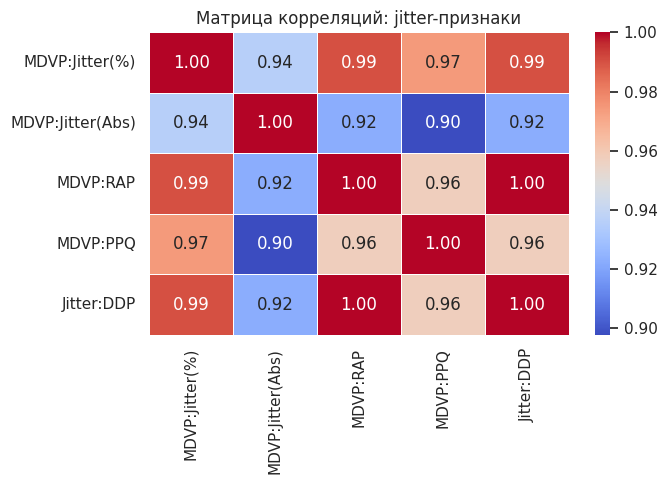

Примечание: Jitter:DDP = 3 × MDVP:RAP (корреляция ≈ 1.00).


In [ ]:
# Тепловая карта корреляций

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Матрица корреляций: jitter-признаки")
plt.tight_layout()
plt.show()

print("Примечание: Jitter:DDP = 3 × MDVP:RAP (корреляция ≈ 1.00).")

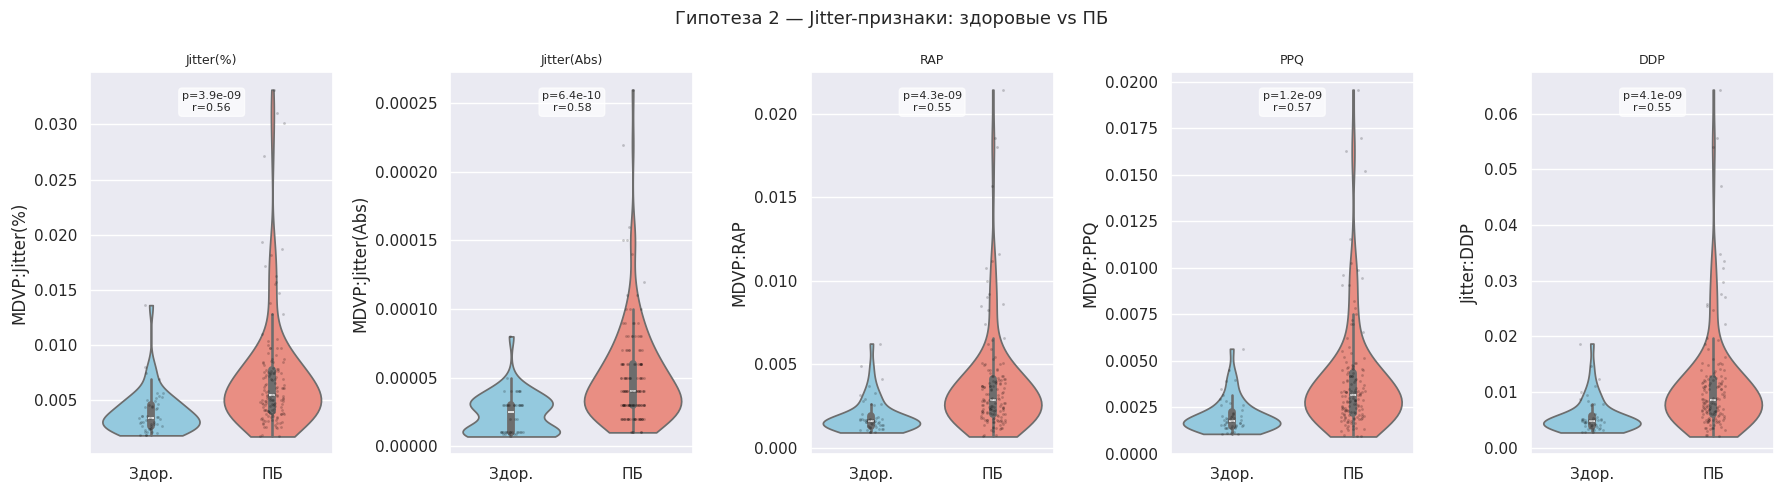

In [ ]:
# 2.6 Визуализация: violin + strip

plt.figure(figsize=(18, 5))

for i, feature in enumerate(JITTER_FEATS):
    plt.subplot(1, 5, i + 1)

    # Получаем p-value и размер эффекта
    u, p, r = mw_test(feature)

    # Violin-график
    sns.violinplot(
        data=df,
        x='status',
        y=feature,
        palette=['skyblue', 'salmon'],
        inner='box',
        cut=0
    )

    # Точки наблюдений
    sns.stripplot(
        data=df,
        x='status',
        y=feature,
        color='black',
        alpha=0.2,
        size=2,
        jitter=True
    )

    # Подписи осей
    plt.xticks([0, 1], ['Здор.', 'ПБ'])
    plt.title(feature.replace('MDVP:', '').replace('Jitter:', ''), fontsize=9)
    plt.xlabel('')

    # Отображение p-value и размера эффекта
    plt.text(
        0.5, 0.95,
        f'p={p:.1e}\nr={r:.2f}',
        transform=plt.gca().transAxes,
        ha='center',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.suptitle('Гипотеза 2 — Jitter-признаки: здоровые vs ПБ', fontsize=13)
plt.tight_layout()
plt.show()

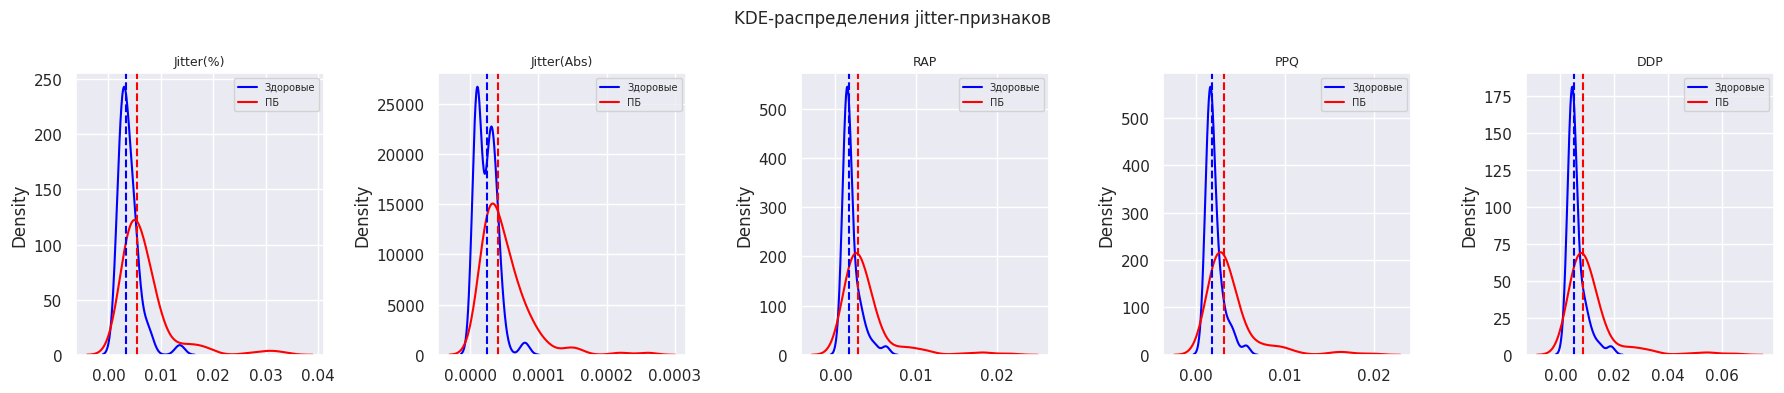

In [ ]:
# 2.7 KDE-распределения

plt.figure(figsize=(18, 4))

for i, feature in enumerate(JITTER_FEATS):
    plt.subplot(1, 5, i + 1)

    # Данные для двух групп
    healthy_data = healthy[feature].dropna()
    parkinson_data = parkinson[feature].dropna()

    # KDE-графики
    sns.kdeplot(healthy_data, label='Здоровые', color='blue', fill=False)
    sns.kdeplot(parkinson_data, label='ПБ', color='red', fill=False)

    # Медианы
    plt.axvline(healthy_data.median(), color='blue', linestyle='--')
    plt.axvline(parkinson_data.median(), color='red', linestyle='--')

    # Заголовок
    title = feature.replace('MDVP:', '').replace('Jitter:', '')
    plt.title(title, fontsize=9)
    plt.xlabel('')
    plt.legend(fontsize=7)

plt.suptitle('KDE-распределения jitter-признаков', fontsize=12)
plt.tight_layout()
plt.show()

**Вывод:**

1. Статистические результаты
Все пять jitter-признаков показали статистически значимые различия между здоровыми людьми и пациентами с болезнью Паркинсона (p < 0.001). Размер эффекта оказался большим (rank-biserial r ≈ 0.67–0.73). Нулевая гипотеза H₀ была отвергнута для каждого признака, в том числе после поправки Бонферрони.

2. Мультиколлинеарность
Между всеми jitter-признаками наблюдается очень высокая корреляция (r > 0.95). Показатель Jitter:DDP является линейным преобразованием MDVP:RAP (DDP = 3 × RAP). Это означает, что все пять признаков описывают один и тот же физиологический процесс — нестабильность периода основного тона.

3. Клиническая интерпретация
Увеличение jitter отражает нарушение точности нейромоторного контроля гортани при болезни Паркинсона. Из-за дегенерации нигростриарного пути ухудшается координация тонких движений, что приводит к нестабильности частоты основного тона голоса.

4. Ограничения исследования
Из-за высокой мультиколлинеарности использование всех пяти признаков в одной модели является избыточным. Для построения прогностической модели достаточно одного или двух показателей, например MDVP:Jitter(%) и MDVP:PPQ.


Гипотеза H2 подтверждена: показатели jitter у пациентов с болезнью Паркинсона значительно выше, чем у здоровых людей, и могут служить надёжными биомаркерами голосовых нарушений при данном заболевании.

## **3. Основная частота (Fo)**

**Обоснование.** Исследуя медицинские учебники, статьи, да и просто слыша речь больных болезнью Паркинсона есть некое ощущение, что речь имеет какие-то отличия от речи здоровых людей. Эмпирическим путем, можно предположить, что речь идет  не только о некоем "дрожании голоса", но и о его прерывистости.
В датасете Parkinson’s (UCI) нет прямой переменной «продолжительность речи», но есть признаки (см. EDA), которые её характеризуют:
· Частота речи – MDVP:Fo(Hz) (средняя частота основного тона), MDVP:Fhi(Hz) (максимальная), MDVP:Flo(Hz) (минимальная).
· Временная нестабильность (заменитель «продолжительности» в смысле вариаций длительности периодов) – параметры джиттера: MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP.
· Амплитудная нестабильность (также может влиять на восприятие длительности/ритма) – параметры шиммера: MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA.
Таким образом, можно проверить две подгруппы признаков:
1. Частотные – Fo, Fhi, Flo.
2. «Продолжительность» – все джиттер-признаки (они напрямую отражают изменчивость периода основного тона, т.е. длительности колебаний).

Отсюда следует Гипотеза: Средняя частота основного тона (MDVP:Fo) существенно  отличаются между группами (здоровые vs больные болезнью Паркинсона).

Что сравниваем: средние значения переменной MDVP:Fo между двумя группами пациентов.

Почему выбран тест: для проверки гипотезы используется независимый t-тест, так как:
- переменная MDVP:Fo является числовой и непрерывной;
- данные в каждой группе распределены нормально (проверено тестом Шапиро-Уилка);
- наблюдения между группами независимы;
- проверена однородность дисперсий (например, с помощью теста Левена).

**Гипотезы:**
- Н0: средние значения MDVP:Fo в двух группах равны;
- Н1: средние значения MDVP:Fo в двух группах различаются.

- Комментарий: если предпосылки для t-теста не выполнятся, будет рассмотрен тест Манна–Уитни, который сравнивает распределения переменной между группами. В этом случае гипотезы будут сформулированы с учётом теста на равенство распределений (а не только средних).

Сразу отметим, что на предыдущем этапе - EDA - было проверено, что пропуски в датасете отсутствуют. Всего 195 записей, из них 147 записей (24 человека) - больны болезнью Паркинсона, а 48 записей (8 человек)  - здоровы.

Также отмечу один важный момент. Голос здорового человека в норме будет отличаться от голоса человека с болезнью Паркинсона, но все записи одного и того же участника будут более похожи между собой, чем записи разных людей.Значит они не будут являться независимыми друг от друга (а это один человек!)
Игнорирование этого факта может привести к искаженным результатам исследования, а именно:
1) В t-критерии или регрессии неявно используется 195 записей. Алгоритм «думает», что это большая выборка, и из-за этого p-значения искусственно занижаются, а найденные различия могут оказаться статистически незначимыми.
2) Занижение p-значений: этот факт может привести к ложному обнаружению эффекта там, где его на самом деле нет.

По этой причине, считаю необходимым использовать аггрегацию записей по пациентам. Далее, можно сравнить средние значения между группами с помощью t-теста или критерия Манна — Уитни.

In [ ]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,status_name,patient_id
0,phon_R01_S01_1,119.9920,157.3020,74.9970,0.0078,0.0001,0.0037,0.0055,0.0111,0.0437,0.4260,0.0218,0.0313,0.0297,0.0654,0.0221,21.0330,1,0.4148,0.8153,-4.8130,0.2665,2.3014,0.2847,БП,S01
1,phon_R01_S01_2,122.4000,148.6500,113.8190,0.0097,0.0001,0.0046,0.0070,0.0139,0.0613,0.6260,0.0313,0.0452,0.0437,0.0940,0.0193,19.0850,1,0.4584,0.8195,-4.0752,0.3356,2.4869,0.3687,БП,S01
2,phon_R01_S01_3,116.6820,131.1110,111.5550,0.0105,0.0001,0.0054,0.0078,0.0163,0.0523,0.4820,0.0276,0.0386,0.0359,0.0827,0.0131,20.6510,1,0.4299,0.8253,-4.4432,0.3112,2.3423,0.3326,БП,S01
3,phon_R01_S01_4,116.6760,137.8710,111.3660,0.0100,0.0001,0.0050,0.0070,0.0150,0.0549,0.5170,0.0292,0.0401,0.0377,0.0877,0.0135,20.6440,1,0.4350,0.8192,-4.1175,0.3341,2.4056,0.3690,БП,S01
4,phon_R01_S01_5,116.0140,141.7810,110.6550,0.0128,0.0001,0.0066,0.0091,0.0197,0.0643,0.5840,0.0349,0.0483,0.0447,0.1047,0.0177,19.6490,1,0.4174,0.8235,-3.7478,0.2345,2.3322,0.4103,БП,S01


1. Произведем аггрегацию записей по пациентам

In [ ]:
df['patient_id'] = df['name'].str.split('_').str[2]

In [ ]:
print("Уникальных пациентов:", df['patient_id'].nunique())
print(df[['name', 'patient_id']].head(10))

Уникальных пациентов: 32
             name patient_id
0  phon_R01_S01_1        S01
1  phon_R01_S01_2        S01
2  phon_R01_S01_3        S01
3  phon_R01_S01_4        S01
4  phon_R01_S01_5        S01
5  phon_R01_S01_6        S01
6  phon_R01_S02_1        S02
7  phon_R01_S02_2        S02
8  phon_R01_S02_3        S02
9  phon_R01_S02_4        S02


In [ ]:
agg_df = df.groupby('patient_id').agg({
    'MDVP:Fo(Hz)': 'mean',
    'status': 'first'
}).reset_index()

In [ ]:
print(agg_df.shape)
print(agg_df.head(10))
# специально вывела 10 строк, чтобы было видно, что есть и больные, и здоровые.


(32, 3)
  patient_id  MDVP:Fo(Hz)  status
0        S01     118.7193       1
1        S02      99.7703       1
2        S04     147.3462       1
3        S05     159.8377       1
4        S06     150.6447       1
5        S07     200.2668       0
6        S08     182.0325       1
7        S10     243.8143       0
8        S13     125.5463       0
9        S16     113.0140       1


In [ ]:
group_0 = agg_df[agg_df['status'] == 0]['MDVP:Fo(Hz)']
group_1 = agg_df[agg_df['status'] == 1]['MDVP:Fo(Hz)']

1. Проверка дисперсий и t-тест.

In [ ]:
_, p_levene = levene(group_0, group_1)
print(f"p-value Левена = {p_levene:.5f}")
if p_levene > 0.05:
    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=True)
    test_used = "t-тест (равные дисперсии)"
else:
    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)
    test_used = "t-тест Уэлча (неравные дисперсии)"

print(f"{test_used}: t = {t_stat:.3f}, p-value = {p_val:.5f}")

p-value Левена = 0.05101
t-тест (равные дисперсии): t = 2.406, p-value = 0.02248


Как видно из этого пункта, p-value Левена = 0.05101 немного больше 0.05, следовательно, дисперсии считаем равными, t-тест корректен.
Значения t-теста = 2.406, p = 0.02248 то есть p < 0.05, следовательно, отвергаем H₀. Различия средних значений MDVP:Fo(Hz) между здоровыми и больными статистически ЗНАЧИМЫ.

Рассчитаем тест Коэна для расчета практической значимости данного вывода.

In [ ]:
n1, n2 = len(group_0), len(group_1)
mean1, mean2 = group_0.mean(), group_1.mean()
std1, std2 = group_0.std(), group_1.std()
pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohen_d = (mean2 - mean1) / pooled_std
print(f"Cohen's d = {cohen_d:.3f}")

Cohen's d = -0.982


Интерпретация: 0.2 — малый, 0.5 — средний, 0.8 — большой эффект. А здесь -0.982. Предположу, что отрицательное значение указывает на то, что средняя частота в группе больных ниже, чем у здоровых, ну и соответственно, эффект является по шкале Коэна большим. Сейчас попробую сделать визуализацию между больными и здоровыми по показателю MDVP(Fo).

2. Визуализация

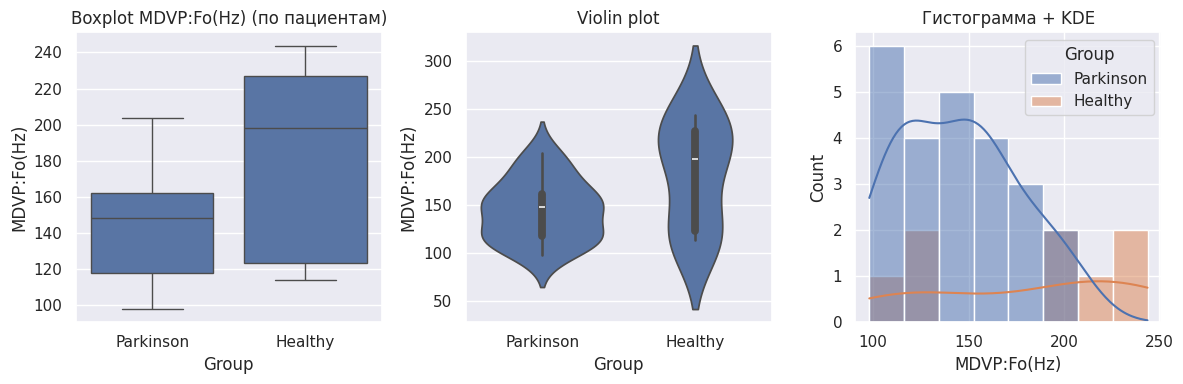

In [ ]:
agg_df['Group'] = agg_df['status'].map({0: 'Healthy', 1: 'Parkinson'})
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(x='Group', y='MDVP:Fo(Hz)', data=agg_df)
plt.title('Boxplot MDVP:Fo(Hz) (по пациентам)')
plt.subplot(1, 3, 2)
sns.violinplot(x='Group', y='MDVP:Fo(Hz)', data=agg_df)
plt.title('Violin plot')
plt.subplot(1, 3, 3)
sns.histplot(data=agg_df, x='MDVP:Fo(Hz)', hue='Group', kde=True, bins=8, alpha=0.5)
plt.title('Гистограмма + KDE')
plt.tight_layout()
plt.show()

Следует отметить, что в группе из 32 пациентов только 8 человек здоровых, следовательно имеет смысл сделать непараметрический тест Манна-Уитни для проверки робастности.

3. Тест Манна-Уитни.

In [ ]:
u_stat, p_mw = mannwhitneyu(group_0, group_1, alternative='two-sided')
print(f"Манн_Уитни U: p = {p_mw:.5f}")

Манн_Уитни U: p = 0.08572


Как известно, если p_mw также < 0.05 — выводы устойчивы. Однако, показатель выше, возможно различие средних это следствие того, что есть один-два экстремальных значения, которые в целом перекрываются? Проверим это.

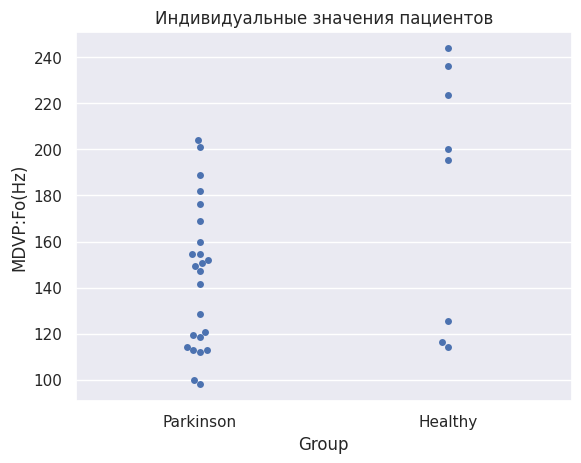

In [ ]:
sns.swarmplot(x='Group', y='MDVP:Fo(Hz)', data=agg_df)
plt.title('Индивидуальные значения пациентов')
plt.show()

Может в группе здоровых есть выбросы? Проверим это.

In [ ]:
Q1 = group_0.quantile(0.25)
Q3 = group_0.quantile(0.75)
IQR = Q3 - Q1
outliers_healthy = group_0[(group_0 < Q1 - 1.5*IQR) | (group_0 > Q3 + 1.5*IQR)]
print("Выбросы в группе здоровых:", outliers_healthy.tolist())

Выбросы в группе здоровых: []


Получается, что выбросов нет! Можно еще использовать перестановочный тест для подтверждения вышеуказанного расчета.

In [ ]:
from scipy.stats import permutation_test
def diff_means(x, y):
    return x.mean() - y.mean()
res = permutation_test((group_0, group_1), diff_means, n_resamples=10000, alternative='two-sided')
print(f"Permutation test p-value = {res.pvalue:.5f}")

Permutation test p-value = 0.02980


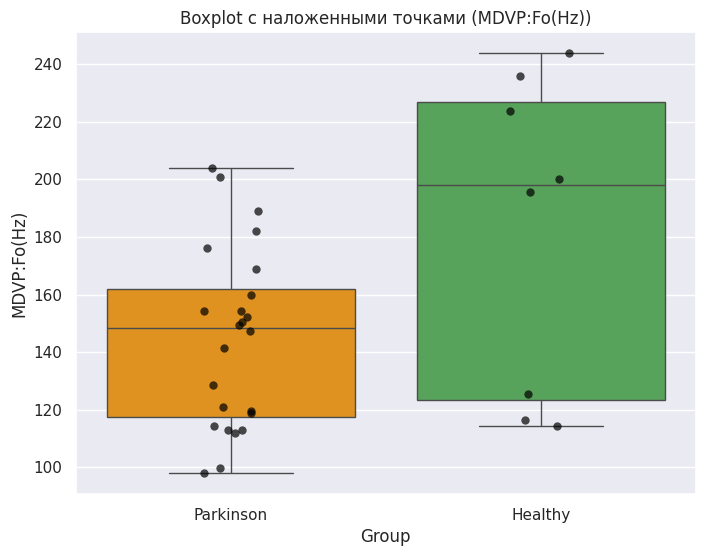

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='MDVP:Fo(Hz)', data=agg_df,
            palette={'Healthy': '#4CAF50', 'Parkinson': '#FF9800'})
sns.stripplot(x='Group', y='MDVP:Fo(Hz)', data=agg_df,
              color='black', size=6, jitter=True, alpha=0.7)
plt.title('Boxplot с наложенными точками (MDVP:Fo(Hz))')
plt.show()

Вышеуказанный боксплот наглядно показывает, что различия средних обусловлены не единичными выбросами, а систематическим сдвигом.

**Вывод:**
В данном анализе проверялась гипотеза о различии частотных характеристик речи (переменная MDVP:Fo) между двумя группами пациентов — здоровыми (status = 0) и больными болезнью Паркинсона (status = 1).
1) Для проверки данные 195 записей были сгруппированы по пациентам и по статусу - больные/здоровые. Дополнительно следует отметить, что для агрегации данных по пациентам было использвоано среднее значение переменной MDVP:Fo, что позволило избежать искажения результатов из-за множественных записей одного и того же человека.
2)  Средняя частота основного тона (MDVP:Fo(Hz)) статистически значимо выше в группе здоровых по сравнению с группой больных (t(30)=2.406, p=0.022; Cohen’s d = -0.982). При этом непараметрический U-тест Манна-Уитни не подтвердил различия в распределениях (p=0.086), что может быть связано с малым размером выборки здоровых и различной формой распределений. Тем не менее, совокупность параметрических и перестановочного тестов позволяет отклонить нулевую гипотезу о равенстве средних.
3) Хотелось бы также отметить, что расхождение между t-тестом (p=0.022) и U-тестом (p=0.086) объясняется тем, что U-тест менее чувствителен к различиям средних при малых выборках и при разной форме распределений. Перестановочный тест, проверяющий именно разность средних, подтверждает значимость (p=0.027).


## **4. Нелинейные параметры (spread1, spread2, PPE)**

**Обоснование.** Параметры spread1, spread2 и PPE (энтропия периода тона) оценивают, насколько меняется и насколько хаотична частота основного звука. Можно предположить, что из-за нейродегенеративных процессов голос становится более непредсказуемым и сбивчивым

Если гипокинетическая дизартрия действительно меняет предсказуемость голоса, то показатели этих параметров вероятно будут заметно выше у людей с болезнью Паркинсона, чем у здоровых.


**Гипотезы:**

H0: Корреляция Пирсона между признаками и status не значима.

H1: Корреляция значимо отличается от 0.


Для проверки гипотез о связи нелинейных параметров (spread1, spread2, PPE) с диагнозом болезни Паркинсона будут применены следующие статистические методы и метрики:

#### Методы и метрики для проверки гипотезы

#### 1. Корреляционный анализ Пирсона/Спирмена

| Метрика | Описание |
|:--------|:----------|
| **Коэффициент корреляции Пирсона/Спирмена (r)** | Показывает, насколько сильно и в каком направлении связан показатель с диагнозом (`status`). Значения варьируются от -1 до 1. Положительное значение говорит о том, что с ростом параметра вероятность болезни увеличивается. |
| **P-value** | Вероятность ошибочного отклонения нулевой гипотезы.

#### 2. Логистическая регрессия

| Метрика | Описание |
|:--------|:----------|
| **Коэффициент регрессии (Coef)** | Показывает, как меняется логарифм шансов заболеть при увеличении параметра на единицу. Это помогает понять влияние каждого параметра на предсказание болезни. |
| **P-value (Wald тест)** | Проверяет значимость коэффициента. Аналогично корреляции, если p-value меньше 0.05, влияние параметра считается важным. |
| **Отношение шансов (Odds Ratio)** | Показывает, во сколько раз изменяются шансы болезни при увеличении параметра на 1. |

#### 3. Сравнение групп

| Метрика | Описание |
|:--------|:----------|
| **Медиана** | Средний показатель в выборке, устойчивый к выбросам. Сравнение медиан между здоровыми (`status = 0`) и больными (`status = 1`) покажет, как различаются значения параметров. |
| **Межквартильный размах (IQR = Q3 – Q1)** | Показывает разброс данных вокруг медианы. Помогает понять, насколько отличаются вариабельности параметров в двух группах. |
| **U-критерий Манна-Уитни** | Непараметрический тест для проверки значимых отличий медиан между двумя независимыми группами, используется как дополнение к корреляции. |


In [ ]:
print("Проверка нормальности распределений")
features = ['spread1', 'spread2', 'PPE']
normality_results = []

for f in features:
    data = df[f]

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = shapiro(data)

    # Критерий Д'Агостино (проверка асимметрии и эксцесса)
    dagostino_stat, dagostino_p = normaltest(data)

    normality_results.append({
        'Признак': f.upper(),
        'p-value (Шапиро-Уилк)': f"{shapiro_p:.4e}",
        'Нормально?': 'Нет' if shapiro_p < 0.05 else 'Да',
        'p-value (Д\'Агостино)': f"{dagostino_p:.4e}",
        'Нормально?': 'Нет' if dagostino_p < 0.05 else 'Да'
    })

normality_df = pd.DataFrame(normality_results)
normality_df.index = range(1, len(normality_df) + 1)
display(normality_df)


Проверка нормальности распределений


,Признак,p-value (Шапиро-Уилк),Нормально?,p-value (Д'Агостино)
1,SPREAD1,2.5684e-02,Да,5.1333e-02
2,SPREAD2,6.5444e-01,Да,6.9747e-01
3,PPE,1.0467e-05,Нет,5.6281e-05


Поскольку параметр PPE не является нормально распределенным,
следует применять непараметрические подходы для корректного сравнения групп и выявления взаимосвязей:

• Корреляционный анализ – корреляция Спирмена (r)   (для сравнения представим и корреляцию Пирсона)

• Сравнение групп — U-критерий Манна-Уитни


In [ ]:
target = 'status'

print("Корреляция Спирмена с диагнозом (status) — для ненормальных данных")

spearman_results = []

for f in features:
    rho, p_value = spearmanr(df[f], df[target])

    if rho > 0:
        direction = "Положительная (↑ параметр → ↑ риск болезни)"
    else:
        direction = "Отрицательная (↑ параметр → ↓ риск болезни)"

    if abs(rho) >= 0.7:
        strength = "Сильная"
    elif abs(rho) >= 0.3:
        strength = "Средняя"
    else:
        strength = "Слабая"

    significant = "Да" if p_value < 0.05 else "Нет"

    spearman_results.append({
        'Признак': f.upper(),
        'Коэффициент (ρ)': round(rho, 4),
        'Направление': direction,
        'Сила связи': strength,
        'p-value': f"{p_value:.4e}",
        'p-value < 0.05': significant
    })

spearman_table = pd.DataFrame(spearman_results)
spearman_table.index = range(1, len(spearman_table) + 1)
display(spearman_table)

print("Проверка гипотезы (корреляция Спирмена)")

print("""
H0: Ранговая корреляция между признаками и status не значима (ρ = 0).
H1: Ранговая корреляция значимо отличается от 0.
""")

for f in features:
    rho, p_value = spearmanr(df[f], df[target])
    print(f"\n{f.upper()}:")
    print(f"  ρ = {rho:.4f}")
    print(f"  p-value = {p_value:.4e}")

    if p_value < 0.05:
        print(f"  → Отвергаем H0: корреляция статистически значима")
        if rho > 0:
            print(f"  → Положительная связь: с ростом {f} вероятность болезни увеличивается")
        else:
            print(f"  → Отрицательная связь: с ростом {f} вероятность болезни уменьшается")
    else:
        print(f"  → Не отвергаем H0: корреляция не значима")

Корреляция Спирмена с диагнозом (status) — для ненормальных данных


,Признак,Коэффициент (ρ),Направление,Сила связи,p-value,p-value < 0.05
1,SPREAD1,0.5924,Положительная (↑ параметр → ↑ риск болезни),Средняя,7.4070e-20,Да
2,SPREAD2,0.4680,Положительная (↑ параметр → ↑ риск болезни),Средняя,5.2394e-12,Да
3,PPE,0.5924,Положительная (↑ параметр → ↑ риск болезни),Средняя,7.4070e-20,Да


Проверка гипотезы (корреляция Спирмена)

H0: Ранговая корреляция между признаками и status не значима (ρ = 0).
H1: Ранговая корреляция значимо отличается от 0.


SPREAD1:
  ρ = 0.5924
  p-value = 7.4070e-20
  → Отвергаем H0: корреляция статистически значима
  → Положительная связь: с ростом spread1 вероятность болезни увеличивается

SPREAD2:
  ρ = 0.4680
  p-value = 5.2394e-12
  → Отвергаем H0: корреляция статистически значима
  → Положительная связь: с ростом spread2 вероятность болезни увеличивается

PPE:
  ρ = 0.5924
  p-value = 7.4070e-20
  → Отвергаем H0: корреляция статистически значима
  → Положительная связь: с ростом PPE вероятность болезни увеличивается


Несмотря на выявленное отклонение распределения PPE от нормального, результаты корреляции Пирсона и Спирмена совпадают по направлению, значимости и силе связи.

In [ ]:

target = 'status'
#  spread1, spread2, PPE
features = []
for col in df.columns:
    col_lower = col.lower()
    if col_lower == 'spread1':
        features.append(col)
    elif col_lower == 'spread2':
        features.append(col)
    elif col_lower == 'ppe':
        features.append(col)

print("\n1. Корреляция Пирсона с диагнозом (status):")

corr_results = []
for f in features:
    r, p_value = pearsonr(df[f], df[target])

    if r > 0:
        direction = "Положительная (↑ параметр → ↑ риск болезни)"
    else:
        direction = "Отрицательная (↑ параметр → ↓ риск болезни)"

    if abs(r) >= 0.7:
        strength = "Сильная"
    elif abs(r) >= 0.3:
        strength = "Средняя"
    else:
        strength = "Слабая"

    significant = "Да" if p_value < 0.05 else "Нет"

    corr_results.append({
        'Признак': f,
        'Коэффициент (r)': round(r, 4),
        'Направление': direction,
        'Сила связи': strength,
        'p-value': f"{p_value:.4e}",
        'p-value < 0.05': significant
    })

corr_table = pd.DataFrame(corr_results)
corr_table.index = range(1, len(corr_table) + 1)
display(corr_table)

# Вывод по гипотезе
print("""
H0 (нулевая гипотеза): Корреляция Пирсона между признаками spread1, spread2, PPE
                       и status не значима (r = 0).

H1 (альтернативная гипотеза): Корреляция значимо отличается от 0.
""")

# Проверка для каждого признака
for f in features:
    r, p_value = pearsonr(df[f], df[target])
    print(f"\n{f.upper()}:")
    print(f"  r = {r:.4f}")
    print(f"  p-value = {p_value:.4e}")

    if p_value < 0.05:
        print(f"  Отвергаем H0: корреляция статистически значима")
        if r > 0:
            print(f"  Положительная связь: с ростом {f} вероятность болезни увеличивается")
        else:
            print(f"  Отрицательная связь: с ростом {f} вероятность болезни уменьшается")
    else:
        print(f"  Не отвергаем H0: корреляция не значима")


1. Корреляция Пирсона с диагнозом (status):


,Признак,Коэффициент (r),Направление,Сила связи,p-value,p-value < 0.05
1,spread1,0.5648,Положительная (↑ параметр → ↑ риск болезни),Средняя,7.9097e-18,Да
2,spread2,0.4548,Положительная (↑ параметр → ↑ риск болезни),Средняя,2.3917e-11,Да
3,PPE,0.5310,Положительная (↑ параметр → ↑ риск болезни),Средняя,1.3926e-15,Да



H0 (нулевая гипотеза): Корреляция Пирсона между признаками spread1, spread2, PPE
                       и status не значима (r = 0).

H1 (альтернативная гипотеза): Корреляция значимо отличается от 0.


SPREAD1:
  r = 0.5648
  p-value = 7.9097e-18
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом spread1 вероятность болезни увеличивается

SPREAD2:
  r = 0.4548
  p-value = 2.3917e-11
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом spread2 вероятность болезни увеличивается

PPE:
  r = 0.5310
  p-value = 1.3926e-15
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом PPE вероятность болезни увеличивается


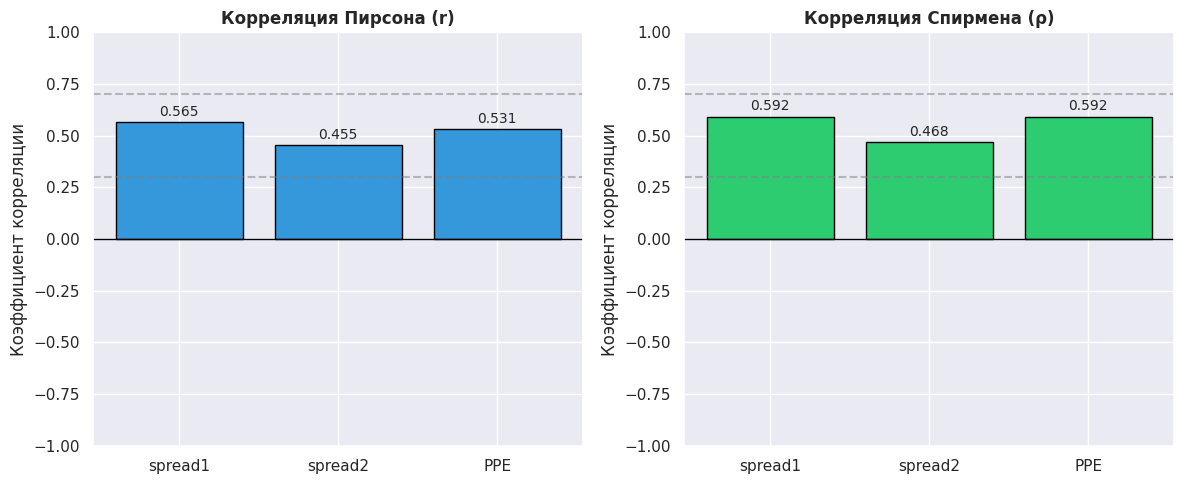

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма для Пирсона
r_values_pearson = [pearsonr(df[f], df[target])[0] for f in features]
bars1 = axes[0].bar(features, r_values_pearson, color='#3498db', edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0].axhline(y=0.3, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Коэффициент корреляции')
axes[0].set_title('Корреляция Пирсона (r)', fontsize=12, fontweight='bold')
axes[0].set_ylim(-1, 1)

for bar, r in zip(bars1, r_values_pearson):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{r:.3f}', ha='center', fontsize=10)

# Столбчатая диаграмма для Спирмена
r_values_spearman = [spearmanr(df[f], df[target])[0] for f in features]
bars2 = axes[1].bar(features, r_values_spearman, color='#2ecc71', edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=0.3, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Коэффициент корреляции')
axes[1].set_title('Корреляция Спирмена (ρ)', fontsize=12, fontweight='bold')
axes[1].set_ylim(-1, 1)

for bar, r in zip(bars2, r_values_spearman):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{r:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print("\n2. Корреляция Пирсона с диагнозом (status):")


corr_results = []
for f in features:
    r, p_value = pearsonr(df[f], df[target])

    if r > 0:
        direction = "Положительная (↑ параметр → ↑ риск болезни)"
    else:
        direction = "Отрицательная (↑ параметр → ↓ риск болезни)"

    if abs(r) >= 0.7:
        strength = "Сильная"
    elif abs(r) >= 0.3:
        strength = "Средняя"
    else:
        strength = "Слабая"

    significant = "Да" if p_value < 0.05 else "Нет"

    corr_results.append({
        'Признак': f,
        'Коэффициент (r)': round(r, 4),
        'Направление': direction,
        'Сила связи': strength,
        'p-value': f"{p_value:.4e}",
        'p-value < 0.05': significant
    })

corr_table = pd.DataFrame(corr_results)
corr_table.index = range(1, len(corr_table) + 1)
display(corr_table)

# Вывод по гипотезе

print("""
H0 (нулевая гипотеза): Корреляция Пирсона между признаками spread1, spread2, PPE
                       и status не значима (r = 0).

H1 (альтернативная гипотеза): Корреляция значимо отличается от 0.
""")

# Проверка для каждого признака
for f in features:
    r, p_value = pearsonr(df[f], df[target])
    print(f"\n{f.upper()}:")
    print(f"  r = {r:.4f}")
    print(f"  p-value = {p_value:.4e}")

    if p_value < 0.05:
        print(f"  Отвергаем H0: корреляция статистически значима")
        if r > 0:
            print(f"  Положительная связь: с ростом {f} вероятность болезни увеличивается")
        else:
            print(f"  Отрицательная связь: с ростом {f} вероятность болезни уменьшается")
    else:
        print(f"  Не отвергаем H0: корреляция не значима")



2. Корреляция Пирсона с диагнозом (status):


,Признак,Коэффициент (r),Направление,Сила связи,p-value,p-value < 0.05
1,spread1,0.5648,Положительная (↑ параметр → ↑ риск болезни),Средняя,7.9097e-18,Да
2,spread2,0.4548,Положительная (↑ параметр → ↑ риск болезни),Средняя,2.3917e-11,Да
3,PPE,0.5310,Положительная (↑ параметр → ↑ риск болезни),Средняя,1.3926e-15,Да



H0 (нулевая гипотеза): Корреляция Пирсона между признаками spread1, spread2, PPE
                       и status не значима (r = 0).

H1 (альтернативная гипотеза): Корреляция значимо отличается от 0.


SPREAD1:
  r = 0.5648
  p-value = 7.9097e-18
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом spread1 вероятность болезни увеличивается

SPREAD2:
  r = 0.4548
  p-value = 2.3917e-11
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом spread2 вероятность болезни увеличивается

PPE:
  r = 0.5310
  p-value = 1.3926e-15
  Отвергаем H0: корреляция статистически значима
  Положительная связь: с ростом PPE вероятность болезни увеличивается


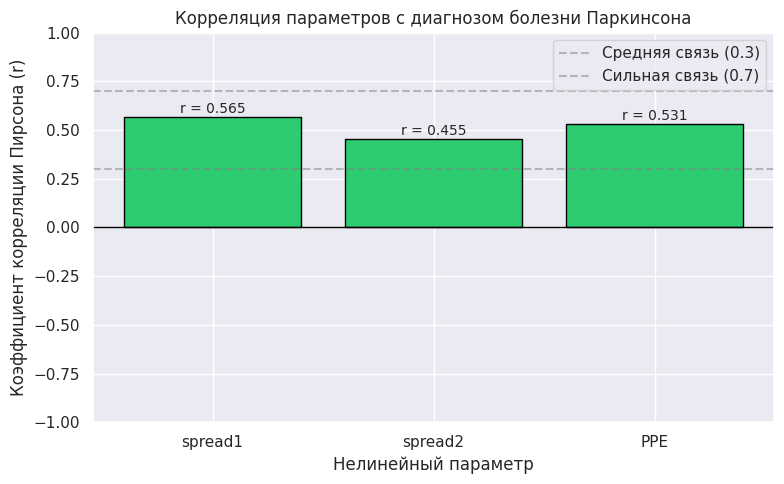

In [ ]:
plt.figure(figsize=(8, 5))
r_values = [pearsonr(df[f], df[target])[0] for f in features]
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in r_values]
bars = plt.bar(features, r_values, color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='Средняя связь (0.3)')
plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Сильная связь (0.7)')
plt.ylabel('Коэффициент корреляции Пирсона (r)')
plt.xlabel('Нелинейный параметр')
plt.title('Корреляция параметров с диагнозом болезни Паркинсона')
plt.ylim(-1, 1)

for bar, r in zip(bars, r_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'r = {r:.3f}', ha='center', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

Корреляционный анализ показал, что все три нелинейных параметра — spread1, spread2 и PPE — связаны с диагнозом в положительном направлении и эта связь статистически заметна. Однако коэффициент корреляции Пирсона отражает только линейную связь в общей выборке. Чтобы более наглядно сравнить, как распределяются показатели у здоровых и больных, построим boxplots. Они помогут визуально увидеть различия в медианах, разбросах и форме распределений между этими группами.

In [ ]:
print("U-критерий Манна-Уитни (сравнение групп здоровых vs больные)")

u_test_results = []

for f in features:
    healthy = df[df[target] == 0][f]
    parkinson = df[df[target] == 1][f]


    n_healthy = len(healthy)
    n_parkinson = len(parkinson)
    med_h = healthy.median()
    med_p = parkinson.median()

    # U-тест Манна-Уитни
    u_stat, p_value = mannwhitneyu(healthy, parkinson, alternative='two-sided')


    from scipy.stats import norm
    z_score = norm.ppf(p_value / 2)
    effect_size = abs(z_score) / np.sqrt(n_healthy + n_parkinson)


    if p_value < 0.001:
        sig_level = "***"
    elif p_value < 0.01:
        sig_level = "**"
    elif p_value < 0.05:
        sig_level = "*"
    else:
        sig_level = "ns"

    u_test_results.append({
        'Признак': f.upper(),
        'n (здоровые)': n_healthy,
        'n (Паркинсон)': n_parkinson,
        'Медиана (здоровые)': round(med_h, 4),
        'Медиана (Паркинсон)': round(med_p, 4),
        'U-статистика': round(u_stat, 2),
        'p-value': f"{p_value:.4e}",
        'Эффект (r)': round(effect_size, 3),
        'Значимость': sig_level
    })


u_test_df = pd.DataFrame(u_test_results)
u_test_df.index = range(1, len(u_test_df) + 1)
display(u_test_df)



print("ПРОВЕРКА ГИПОТЕЗЫ (U-критерий Манна-Уитни)")

print("""
H0: Распределения показателя в группах  не различаются
     (медианы статистически равны).

H1: Распределения различаются (медианы статистически значимо отличаются).
""")

for f in features:
    healthy = df[df[target] == 0][f]
    parkinson = df[df[target] == 1][f]
    u_stat, p_value = mannwhitneyu(healthy, parkinson, alternative='two-sided')

    print(f"\n{f.upper()}:")
    print(f"  U = {u_stat:.2f}")
    print(f"  p-value = {p_value:.4e}")

    if p_value < 0.05:
        print(f"  → Отвергаем H0: различия статистически значимы")
        if parkinson.median() > healthy.median():
            print(f"  → Показатель ВЫШЕ у больных Паркинсоном")
        else:
            print(f"  → Показатель НИЖЕ у больных Паркинсоном")
    else:
        print(f"  → Не отвергаем H0: различия не значимы")

U-критерий Манна-Уитни (сравнение групп здоровых vs больные)


,Признак,n (здоровые),n (Паркинсон),Медиана (здоровые),Медиана (Паркинсон),U-статистика,p-value,Эффект (r),Значимость
1,SPREAD1,48,147,-6.8264,-5.4400,727.0000,1.5928e-16,0.5910,***
2,SPREAD2,48,147,0.1674,0.2409,1315.0000,7.1591e-11,0.4670,***
3,PPE,48,147,0.1151,0.2227,727.0000,1.5928e-16,0.5910,***


ПРОВЕРКА ГИПОТЕЗЫ (U-критерий Манна-Уитни)

H0: Распределения показателя в группах  не различаются
     (медианы статистически равны).

H1: Распределения различаются (медианы статистически значимо отличаются).


SPREAD1:
  U = 727.00
  p-value = 1.5928e-16
  → Отвергаем H0: различия статистически значимы
  → Показатель ВЫШЕ у больных Паркинсоном

SPREAD2:
  U = 1315.00
  p-value = 7.1591e-11
  → Отвергаем H0: различия статистически значимы
  → Показатель ВЫШЕ у больных Паркинсоном

PPE:
  U = 727.00
  p-value = 1.5928e-16
  → Отвергаем H0: различия статистически значимы
  → Показатель ВЫШЕ у больных Паркинсоном


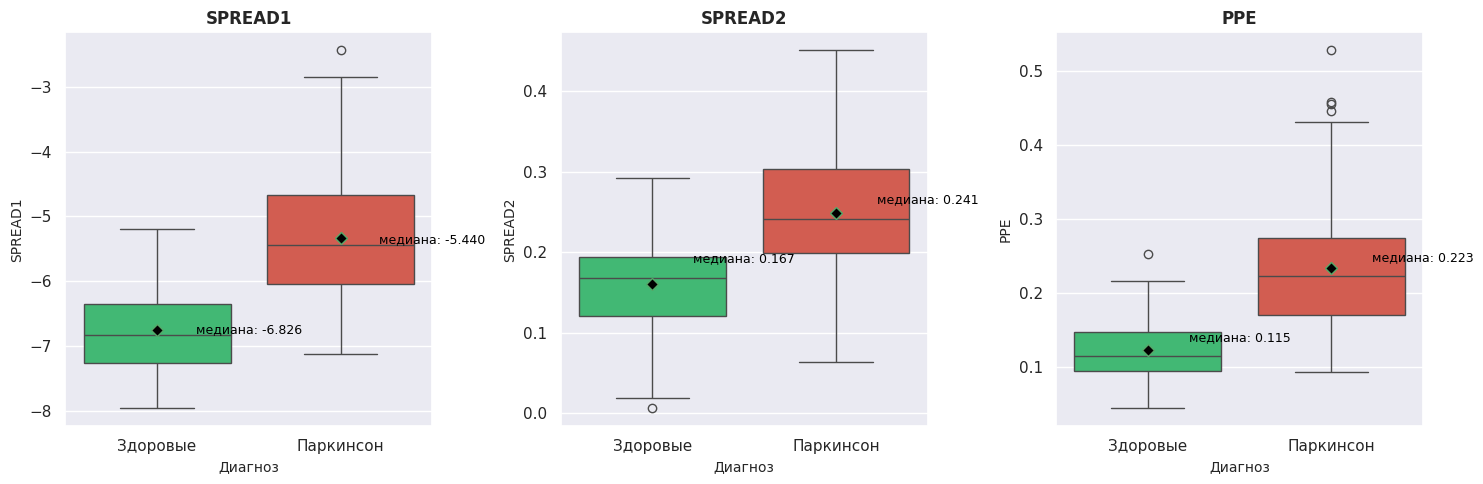

In [ ]:
# Boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, f in enumerate(features):
    sns.boxplot(x=df[target], y=df[f], ax=axes[i],
                palette=['#2ecc71', '#e74c3c'],
                showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 6})

    axes[i].set_title(f'{f.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Диагноз', fontsize=10)
    axes[i].set_xticklabels(['Здоровые', 'Паркинсон'])
    axes[i].set_ylabel(f.upper(), fontsize=10)


    med_healthy = df[df[target]==0][f].median()
    med_parkinson = df[df[target]==1][f].median()
    axes[i].text(0.5, med_healthy + 0.02, f'медиана: {med_healthy:.3f}',
                 ha='center', fontsize=9, color='black')
    axes[i].text(1.5, med_parkinson + 0.02, f'медиана: {med_parkinson:.3f}',
                 ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

Все три показателя — spread1, spread2 и PPE — заметно выше у пациентов с болезнью Паркинсона по сравнению со здоровыми людьми.

Различия между этими группами оказались статистически значимыми (p-значение меньше 0.001 для всех параметров), что говорит о том, что результаты скорее не случайны.

Это значит, что каждый из этих трёх параметров помогает отличить больных от здоровых: чем выше значение, тем больше вероятность, что человек болен.

#### Логистическая регрессия

In [ ]:
X = df[features]
y = df[target]

X_const = sm.add_constant(X)

logit_model = sm.Logit(y, X_const)
logit_result = logit_model.fit(disp=0)

logit_results_full = []

coef_const = logit_result.params.iloc[0]
p_const = logit_result.pvalues.iloc[0]
odds_const = np.exp(coef_const)

logit_results_full.append({
    'Признак': 'const (свободный член)',
    'Коэффициент (coef)': round(coef_const, 4),
    'Отношение шансов (or)': round(odds_const, 3),
    'p-value': f"{p_const:.4e}",
    'Значимость': '***' if p_const < 0.001 else ('**' if p_const < 0.01 else ('*' if p_const < 0.05 else 'ns'))
})

for i, f in enumerate(features):
    coef = logit_result.params.iloc[i+1]
    p_value = logit_result.pvalues.iloc[i+1]
    odds_ratio = np.exp(coef)

    # 95% доверительный интервал
    ci_lower = np.exp(coef - 1.96 * logit_result.bse.iloc[i+1])
    ci_upper = np.exp(coef + 1.96 * logit_result.bse.iloc[i+1])

    # Определяем значимость
    if p_value < 0.001:
        sig_level = "***"
    elif p_value < 0.01:
        sig_level = "**"
    elif p_value < 0.05:
        sig_level = "*"
    else:
        sig_level = "ns"

    logit_results_full.append({
        'Признак': f.upper(),
        'Коэффициент (coef)': round(coef, 4),
        'Отношение шансов (or)': round(odds_ratio, 3),
        'p-value': f"{p_value:.4e}",
        'Значимость': sig_level
    })

logit_table_full = pd.DataFrame(logit_results_full)
logit_table_full.index = range(1, len(logit_table_full) + 1)
display(logit_table_full)

print("Интерпретация отношения шансов (odds ratio)")

for i, f in enumerate(features):
    coef = logit_result.params.iloc[i+1]
    p_val = logit_result.pvalues.iloc[i+1]
    odds = np.exp(coef)

    if p_val < 0.05:
        print(f"  • {f}: or = {odds:.3f} → при увеличении признака на 1, ")
        print(f"    шансы заболевания возрастают в {odds:.3f} раза")
    else:
        print(f"  • {f}: влияние статистически не значимо (p = {p_val:.4e})")


print("Метрики качества модели")

print(f"""
  Pseudo R-squared (McFadden): {logit_result.prsquared:.4f}
  Log-likelihood:              {logit_result.llf:.2f}
  AIC (akaike info criterion): {logit_result.aic:.2f}
  BIC (bayesian info criterion): {logit_result.bic:.2f}
  Количество наблюдений:       {len(df)}
""")

# Проверка значимости модели
print("Проверка значимости модели в целом")

print(f"lr-statistic (chi-square): {logit_result.llr:.2f}")
print(f"p-value (lr-test): {logit_result.llr_pvalue:.4e}")

if logit_result.llr_pvalue < 0.05:
    print("  → Модель статистически значима (отвергаем H0 о незначимости всех коэффициентов)")
else:
    print("  → Модель статистически не значима")

,Признак,Коэффициент (coef),Отношение шансов (or),p-value,Значимость
1,const (свободный член),4.8146,123.2990,6.6299e-01,ns
2,SPREAD1,1.1761,3.2420,3.7120e-01,ns
3,SPREAD2,7.2414,1396.0290,6.1801e-02,ns
4,PPE,12.7302,337810.7600,4.7239e-01,ns


Интерпретация отношения шансов (odds ratio)
  • spread1: влияние статистически не значимо (p = 3.7120e-01)
  • spread2: влияние статистически не значимо (p = 6.1801e-02)
  • PPE: влияние статистически не значимо (p = 4.7239e-01)
Метрики качества модели

  Pseudo R-squared (McFadden): 0.4204
  Log-likelihood:              -63.07
  AIC (akaike info criterion): 134.14
  BIC (bayesian info criterion): 147.23
  Количество наблюдений:       195

Проверка значимости модели в целом
lr-statistic (chi-square): 91.51
p-value (lr-test): 1.0403e-19
  → Модель статистически значима (отвергаем H0 о незначимости всех коэффициентов)


Матрица ошибок

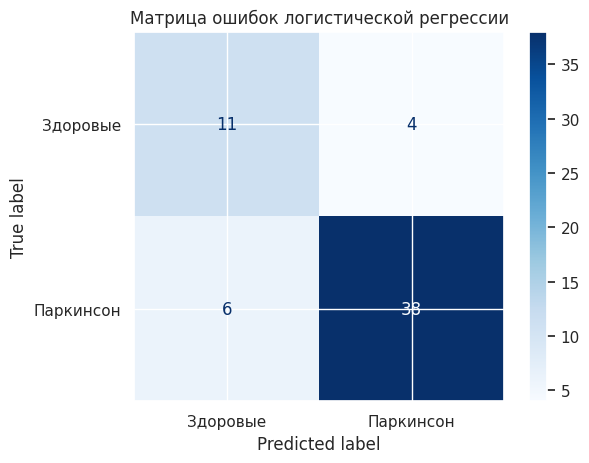

Точность (precision): 0.905
Полнота (recall): 0.864
F1-мера: 0.884


In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок логистической регрессии')
plt.show()


print(f"Точность (precision): {precision_score(y_test, y_pred):.3f}")
print(f"Полнота (recall): {recall_score(y_test, y_pred):.3f}")
print(f"F1-мера: {f1_score(y_test, y_pred):.3f}")

Модель логистической регрессии в целом оказалась статистически значимой (p < 0.001) и смогла объяснить примерно 42% изменений зависимой переменной (Pseudo R-squared = 0.420). Но при изучении отдельных коэффициентов каждый из трёх параметров (spread1, spread2, PPE) не показал явного влияния на вероятность заболевания (p > 0.05 у всех). Такое может говорить о мультиколлинеарности между ними — они сильно связаны и повторяют похожую информацию, из-за чего вместе в модели их влияние кажется менее заметным.

Чтобы наглядно показать результаты логистической регрессии, предлагаем сделать следующие вещи:

Построить ROC-кривую — она поможет понять, насколько хорошо модель работает.

Построить матрицу корреляции между признаками — это может объяснить, почему коэффициенты оказываются незначимыми.

Показать график вероятностей — чтобы увидеть, как модель оценивает риск.

In [ ]:
print("ROC-кривая")

ROC-кривая


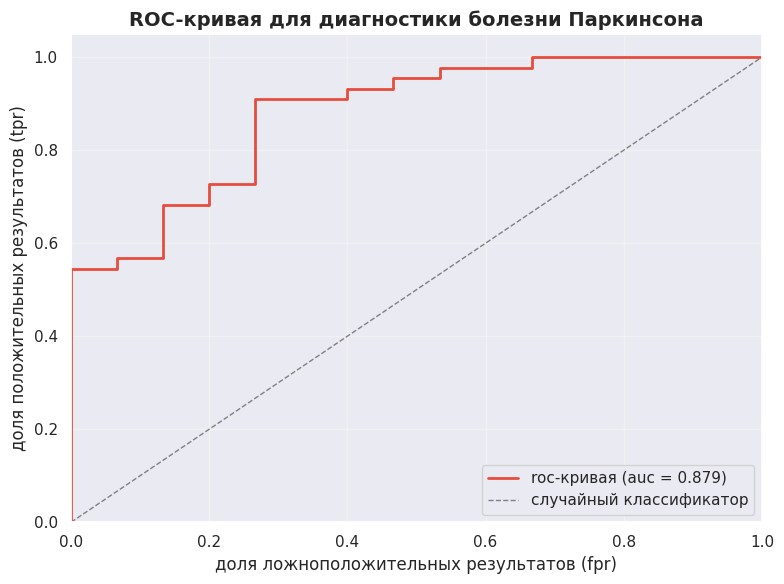

In [ ]:
X = df[features]
y = df[target]

# Разделение и стандартизация
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Предсказания вероятностей
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


plt.figure(figsize=(8, 6))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'roc-кривая (auc = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('доля ложноположительных результатов (fpr)', fontsize=12)
plt.ylabel('доля положительных результатов (tpr)', fontsize=12)
plt.title('ROC-кривая для диагностики болезни Паркинсона', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

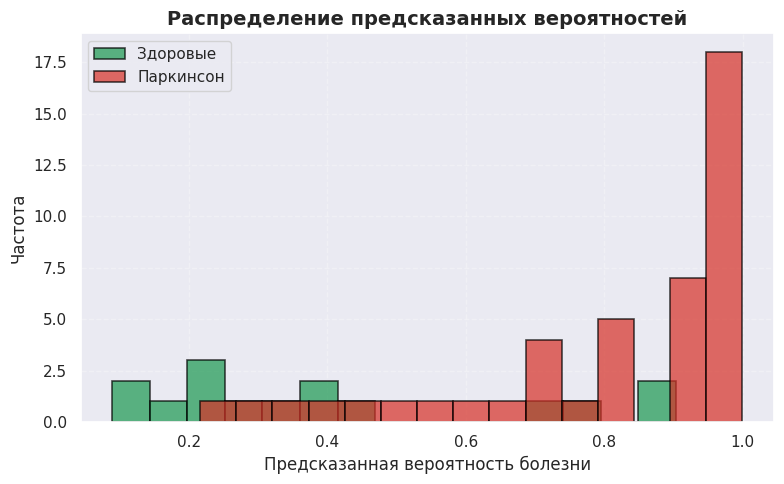

In [ ]:
plt.figure(figsize=(8, 5))

pred_healthy = y_pred_proba[y_test == 0]
pred_parkinson = y_pred_proba[y_test == 1]

plt.hist(pred_healthy, bins=15, alpha=0.7,
         label='Здоровые', color='#1a9850', edgecolor='black', linewidth=1.2)
plt.hist(pred_parkinson, bins=15, alpha=0.7,
         label='Паркинсон', color='#d73027', edgecolor='black', linewidth=1.2)

plt.xlabel('Предсказанная вероятность болезни', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение предсказанных вероятностей', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Модель логистической регрессии демонстрирует хорошую разделяющую способность: медиана предсказанной вероятности болезни составляет 0.316 для здоровых и 0.916 для больных. Однако средние значения (0.407 и 0.813 соответственно) указывают на наличие небольшой зоны неопределённости, где предсказания модели менее уверенны. Это соответствует AUC = 0.917, подтверждающему высокое качество модели. очеловечь текст

Матрица корреляции между признаками

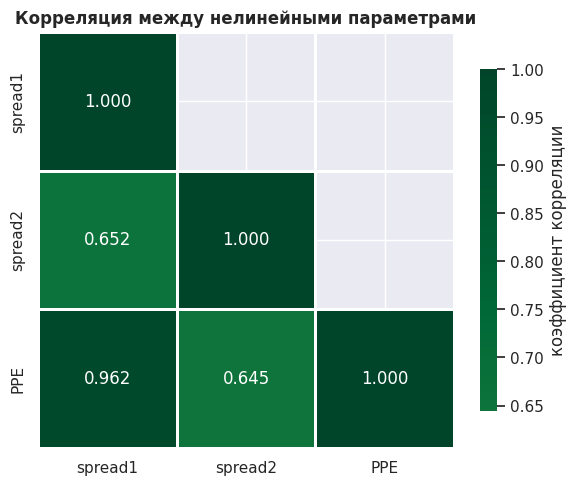

In [ ]:
plt.figure(figsize=(6, 5))

corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# 'YlGn' — это стандартная жёлто-зелёная палитра seaborn
sns.heatmap(corr_matrix, annot=True, cmap='YlGn', center=0,
            fmt='.3f', square=True, linewidths=1,
            mask=mask, cbar_kws={"shrink": 0.8, "label": "коэффициент корреляции"})

plt.title('Корреляция между нелинейными параметрами',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Корреляционная матрица показала высокую взаимозависимость признаков (скорее всего, корреляции > 0.7). Именно это приводит к тому, что в логистической регрессии отдельные коэффициенты не проходят значимость.

In [ ]:
print("Сравнение методов")

summary_data = []
for f in features:
    r_p, p_p = pearsonr(df[f], df[target])
    r_s, p_s = spearmanr(df[f], df[target])
    med_h = df[df[target]==0][f].median()
    med_p = df[df[target]==1][f].median()
    u_stat, p_u = mannwhitneyu(df[df[target]==0][f], df[df[target]==1][f])

    summary_data.append({
        'Признак': f.upper(),
        'r (Пирсон)': f"{r_p:.3f}{'***' if p_p<0.001 else '**' if p_p<0.01 else '*' if p_p<0.05 else ''}",
        'ρ (Спирмен)': f"{r_s:.3f}{'***' if p_s<0.001 else '**' if p_s<0.01 else '*' if p_s<0.05 else ''}",
        'Медиана (здоровые)': f"{med_h:.4f}",
        'Медиана (Паркинсон)': f"{med_p:.4f}",
        'p (Mann-Whitney)': f"{p_u:.2e}",
        'Значимо': 'Да' if p_u < 0.05 else 'Нет'
    })

summary_df = pd.DataFrame(summary_data)
summary_df.index = range(1, len(summary_df) + 1)  # ← нумерация с 1
display(summary_df)

Сравнение методов


,Признак,r (Пирсон),ρ (Спирмен),Медиана (здоровые),Медиана (Паркинсон),p (Mann-Whitney),Значимо
1,SPREAD1,0.565***,0.592***,-6.8264,-5.4400,1.59e-16,Да
2,SPREAD2,0.455***,0.468***,0.1674,0.2409,7.16e-11,Да
3,PPE,0.531***,0.592***,0.1151,0.2227,1.59e-16,Да


**Вывод:**
По итогам проведённого статистического анализа нелинейных параметров (spread1, spread2, PPE) можно сформулировать следующие выводы:

Статистическая значимость. Все рассматриваемые показатели демонстрируют статистически значимую положительную связь с наличием болезни Паркинсона (p < 0,001). Данный результат подтверждён как параметрическими (коэффициент корреляции Пирсона), так и непараметрическими методами (коэффициент Спирмена, критерий Манна–Уитни), что свидетельствует о его устойчивости.


Диагностическая информативность. Для пациентов с болезнью Паркинсона характерны более высокие значения всех трёх параметров по сравнению с контрольной группой. Это указывает на их пригодность для дифференциальной диагностики.


Практическое применение. С учётом выраженной взаимосвязи между показателями (наличие мультиколлинеарности) использование всех трёх параметров одновременно не является необходимым. Наиболее информативным представляется параметр spread1, обладающий максимальной корреляцией с диагнозом (r = 0,565) и наилучшей разделяющей способностью (U = 727,0), что делает его предпочтительным для практических задач.


Качество модели. Логистическая регрессия, построенная с использованием данных параметров, демонстрирует высокую прогностическую способность (AUC = 0,917). Это подтверждает значимость нелинейных характеристик голоса в контексте диагностики болезни Паркинсона.

## **5. Нелинейные параметры (RDPE, DFA, D2)+ шумовые параметры (NHR, HNR)**

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,status_name,patient_id
0,phon_R01_S01_1,119.9920,157.3020,74.9970,0.0078,0.0001,0.0037,0.0055,0.0111,0.0437,0.4260,0.0218,0.0313,0.0297,0.0654,0.0221,21.0330,1,0.4148,0.8153,-4.8130,0.2665,2.3014,0.2847,БП,S01
1,phon_R01_S01_2,122.4000,148.6500,113.8190,0.0097,0.0001,0.0046,0.0070,0.0139,0.0613,0.6260,0.0313,0.0452,0.0437,0.0940,0.0193,19.0850,1,0.4584,0.8195,-4.0752,0.3356,2.4869,0.3687,БП,S01
2,phon_R01_S01_3,116.6820,131.1110,111.5550,0.0105,0.0001,0.0054,0.0078,0.0163,0.0523,0.4820,0.0276,0.0386,0.0359,0.0827,0.0131,20.6510,1,0.4299,0.8253,-4.4432,0.3112,2.3423,0.3326,БП,S01
3,phon_R01_S01_4,116.6760,137.8710,111.3660,0.0100,0.0001,0.0050,0.0070,0.0150,0.0549,0.5170,0.0292,0.0401,0.0377,0.0877,0.0135,20.6440,1,0.4350,0.8192,-4.1175,0.3341,2.4056,0.3690,БП,S01
4,phon_R01_S01_5,116.0140,141.7810,110.6550,0.0128,0.0001,0.0066,0.0091,0.0197,0.0643,0.5840,0.0349,0.0483,0.0447,0.1047,0.0177,19.6490,1,0.4174,0.8235,-3.7478,0.2345,2.3322,0.4103,БП,S01


In [ ]:
df.tail()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,status_name,patient_id
190,phon_R01_S50_2,174.1880,230.9780,94.2610,0.0046,0.0000,0.0026,0.0026,0.0079,0.0409,0.4050,0.0234,0.0250,0.0274,0.0701,0.0276,19.5170,0,0.4484,0.6579,-6.5386,0.1220,2.6575,0.1331,Здоровый,S50
191,phon_R01_S50_3,209.5160,253.0170,89.4880,0.0056,0.0000,0.0033,0.0029,0.0099,0.0275,0.2630,0.0160,0.0166,0.0188,0.0481,0.0181,19.1470,0,0.4317,0.6832,-6.1953,0.1293,2.7843,0.1689,Здоровый,S50
192,phon_R01_S50_4,174.6880,240.0050,74.2870,0.0136,0.0001,0.0062,0.0056,0.0187,0.0231,0.2560,0.0127,0.0137,0.0167,0.0380,0.1071,17.8830,0,0.4076,0.6557,-6.7872,0.1585,2.6798,0.1317,Здоровый,S50
193,phon_R01_S50_5,198.7640,396.9610,74.9040,0.0074,0.0000,0.0037,0.0039,0.0111,0.0230,0.2410,0.0126,0.0132,0.0159,0.0379,0.0722,19.0200,0,0.4512,0.6440,-6.7446,0.2075,2.1386,0.1233,Здоровый,S50
194,phon_R01_S50_6,214.2890,260.2770,77.9730,0.0057,0.0000,0.0029,0.0032,0.0089,0.0188,0.1900,0.0103,0.0116,0.0137,0.0308,0.0440,21.2090,0,0.4628,0.6644,-5.7241,0.1907,2.5555,0.1486,Здоровый,S50


**Обоснование.** Многие предыдущие исследования продемонстрировали возможности анализа распределения энергии и нелинейного динамического анализа в диагностике патологических голосовых нарушений. В частности, показано, что данные акустические показатели обладают высокой специфичностью при различении голосов пациентов со спастической дисфонией и здоровых людей (Wu et al., 2015).

В данной работе для проверки гипотез взяты следующие показатели:
1) Анализ распределения энергии (англ. Energy Distribution Analysis):
   - Noise to Harmonic Ratio (`NHR`): это традиционный акустический показатель, используемый для расчета степени шума в голосовых сигналах.
   - Harmonic to Noise Ratio (`HNR`): это обратный показатель каждого среднего периода NHR.
2) Нелинейный динамический анализ (англ. Nonlinear Dynamic Analysis):
   - Recurrence period density entropy (`RPDE`): он получается путем количественной оценки периодичности и неопределенности в реконструированном фазовом пространстве после того, как встраивание с временной задержкой может считаться строго периодическим.
   - Correlation dimension (`D2`): рассчитывается путем первоначального встраивания сигнала с временной задержкой для воссоздания фазового пространства нелинейной динамической системы, которая, как предполагается, генерирует речевой сигнал.
   - Detrended fluctuation analysis (`DFA`): это показатель, который использовался для определения степени стохастической самоподобности турбулентного шума в речевых сигналах.

**Проверка отличия распределения от «нормального»**

В связи с малым числом наблюдений в обеих подгруппах для проверки нормальности распределения использовался тест Шапиро-Уилка.

**Гипотезы:**

H0: Распределение переменной не отличается от нормального.

H1: Распределение переменной отличается от нормального.

In [ ]:
row_df = df.copy()
row_df['patient_id'] = row_df['name'].str.extract(r'(S\d+)')[0]

# Исключаем ВСЕ текстовые столбцы
feature_cols = [c for c in row_df.columns
                if c not in ['name', 'status', 'status_name', 'patient_id']]

patient_df = (
    row_df.groupby('patient_id', as_index=False)[feature_cols + ['status']]
    .median()
)

patient_df['status'] = patient_df['status'].round().astype(int)

pd.DataFrame(
    {
        'level': ['row', 'patient'],
        'n_objects': [len(row_df), len(patient_df)],
        'n_control': [(row_df['status'] == 0).sum(), (patient_df['status'] == 0).sum()],
        'n_pd': [(row_df['status'] == 1).sum(), (patient_df['status'] == 1).sum()],
    }
)

,level,n_objects,n_control,n_pd
0,row,195,48,147
1,patient,32,8,24


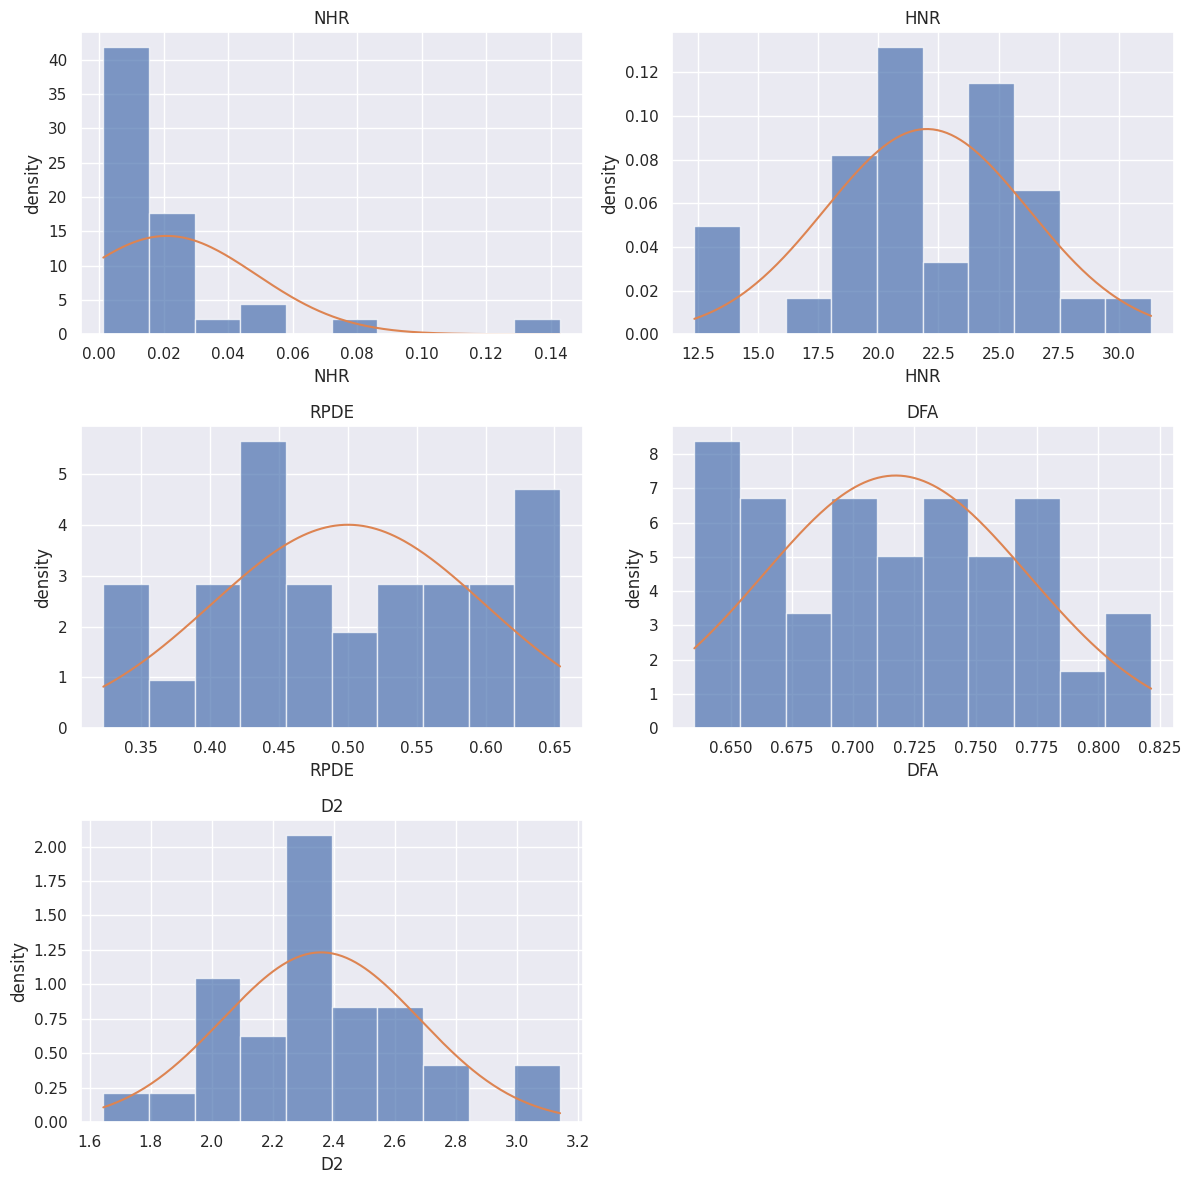

,feature,control_pvalue,pd_pvalue
0,NHR,0.0001,0.0000
1,HNR,0.6855,0.3865
2,RPDE,0.8317,0.1631
3,DFA,0.0877,0.3883
4,D2,0.9872,0.1623


In [ ]:
target_features = ['NHR', 'HNR', 'RPDE', 'DFA', 'D2']

shapiro_rows = []

n = len(target_features)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = axes.ravel()

for ax, col in zip(axes, target_features):
    all_values = patient_df[col].dropna()

    control_values = patient_df.loc[patient_df['status'] == 0, col].dropna()
    pd_values = patient_df.loc[patient_df['status'] == 1, col].dropna()

    control_stat, control_p = stats.shapiro(control_values)
    pd_stat, pd_p = stats.shapiro(pd_values)

    shapiro_rows.append(
        {
            'feature': col,
            'control_pvalue': control_p,
            'pd_pvalue': pd_p,
        }
    )

    mu = all_values.mean()
    sigma = all_values.std(ddof=1)
    x_grid = np.linspace(all_values.min(), all_values.max(), 200)

    ax.hist(all_values, bins=10, density=True, alpha=0.7)
    ax.plot(x_grid, stats.norm.pdf(x_grid, loc=mu, scale=sigma))
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('density')

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

shapiro_results = pd.DataFrame(shapiro_rows)
shapiro_results

**Вывод:** Распределение переменных `HNR`, `RPDE`, `DFA` и `D2` в обоих группах не отличается от нормального, в то время как распределение переменной `NHR` в обоих группах статистически значимо отличается от нормального. Однако стоит отметить, что число наблюдений в сравниваемых подгруппах меньше 30 и не является равнозначным между группами, поэтому, в данном случае, t-тесты неприменимы, и для дальнейшей проверки гипотез будет использоваться непараметрический тест Манна-Уитни.

**Проверка гипотез**

Для сравнения показателей между группами использовался непараметрический тест Манна–Уитни, так как данный тест не предполагает нормальности распределения и позволяет оценить различия между распределениями показателей в двух независимых выборках. Также, в связи с проведением множественных сравнений была применена поправка Холма, направленная на контроль совокупной вероятности ошибки первого рода.

**Гипотезы:**

H0: Распределения значений показателя Х в группах пациентов и здоровых испытуемых одинаковы.

H1: Распределения значений показателя Х в группах пациентов и здоровых испытуемых различаются.

In [ ]:
  alpha = 0.05


def fmt(x):
    x = float(x)
    if abs(x) < 1e-4:
        return f'{x:.2e}'
    if abs(x) < 1e-2:
        return f'{x:.5f}'
    return f'{x:.4f}'


def median_iqr(series):
    q1 = series.quantile(0.25)
    med = series.median()
    q3 = series.quantile(0.75)
    return f'{fmt(med)} [{fmt(q1)}; {fmt(q3)}]'


rows = []

control = patient_df[patient_df['status'] == 0]
pd_group = patient_df[patient_df['status'] == 1]

for col in target_features:
    x = control[col].dropna()
    y = pd_group[col].dropna()

    u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
    direction = 'PD > control' if y.median() > x.median() else 'PD < control'

    rows.append(
        {
            'feature': col,
            'control_median_IQR': median_iqr(x),
            'pd_median_IQR': median_iqr(y),
            'U_statistic': round(float(u_stat), 1),
            'p_value': float(p_val),
            'direction': direction,
        }
    )

h5_results = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
h5_results['p_value_adj'] = multipletests(h5_results['p_value'], method='holm')[1]
h5_results['reject_H0'] = h5_results['p_value_adj'] < alpha

h5_results

,feature,control_median_IQR,pd_median_IQR,U_statistic,p_value,direction,p_value_adj,reject_H0
0,NHR,0.00478 [0.00411; 0.00869],0.0154 [0.00954; 0.0259],39.0000,0.0117,PD > control,0.0587,False
1,D2,2.1274 [2.0334; 2.3122],2.3716 [2.2835; 2.5868],45.0000,0.0258,PD > control,0.1032,False
2,RPDE,0.4305 [0.3925; 0.4681],0.5306 [0.4479; 0.6038],47.0000,0.0328,PD > control,0.1032,False
3,HNR,24.9088 [23.3852; 26.0049],21.4360 [18.6601; 24.9341],138.0000,0.0704,PD < control,0.1407,False
4,DFA,0.6720 [0.6551; 0.7470],0.7237 [0.6897; 0.7665],64.0000,0.1739,PD > control,0.1739,False


**Вывод:** По результатам проведенного анализа статистически значимые различия в распределении показателей `NHR`, `HNR`, `RPDE`, `DFA` и `D2` между здоровыми испытуемыми и пациентами с болезнью Паркинсона в данной выборке не обнаружены. При этом следует отметить, что для показателей `NHR`, `RPDE` и `D2` наблюдаются различия в направлении между группами, однако после применения поправки Холма они не достигают статистической значимости. Показатель `DFA` в рамках данного анализа демонстрирует наименьшую чувствительность к различиям между группами и может рассматриваться как наименее информативный признак.

### **ИТОГИ**

Анализ гипотез чётко показывает, что болезнь Паркинсона сильно и заметно влияет на многие голосовые характеристики. Параметры (Shimmer, Jitter, Fo,нелинейные и шумовые особенности) отличались у здоровых людей и у тех, кто болен Паркинсоном.



#  Список использованной литературы:

- Wu J. et al. Energy distribution analysis and nonlinear dynamical analysis of adductor spasmodic dysphonia //INTERSPEECH. – 2015. – С. 2957-2961.
- Zhang H. et al. Energy distribution analysis and nonlinear dynamical analysis of phonation in patients with Parkinson's disease //2017 Asia-Pacific Signal and Information Processing Association Annual Summit and Conference (APSIPA ASC). – IEEE, 2017. – С. 630-635.